# KR normalization and PCA analysis

This notebook demonstrates how contact/ligation maps are normalized and analyzed to extract large-scale chromatin organization features.

## Purpose

- Apply Knight–Ruiz (KR) matrix balancing to contact/ligation maps  
- Compute the first principal component (PC1)  
- Identify A/B compartment structure from normalized maps  

## Notes

- This notebook is **representative** and focuses on the analysis steps used in the manuscript.
- Input data are aggregated outputs from the in-silico Hi-C pipeline.
- The KR normalization algorithm is adapted from previously published work (see citation below).

## Input data

The notebook expects the following datasets:

- Ligation-derived maps:
  `../../data/processed/digestion_efficiency/`

- Time-resolved contact maps (reduced datasets):
  `../../data/processed/time_resolved_contact_maps/`

- Ensemble contact probabilities:
  `../../data/processed/contact_probabilities/ensemble/`

- Experimental Hi-C data:
  `../../data/processed/experimental/`

Time-resolved contact map files have been reduced to include only the variables required for analysis (`iframes` and `contact_map_average`) in order to limit repository size.

**Note:** The `.npz` datasets required for this notebook are not included in this repository and are available on Zenodo: https://doi.org/10.5281/zenodo.19682913

## Knight–Ruiz normalization

The KR normalization function used here is adapted from:

Rajendra, K. et al. (2017)  
*Genome Contact Map Explorer: a platform for the comparison, interactive visualization and analysis of genome contact maps.*  
Nucleic Acids Research, 45(17):e152.

In [2]:
import hoomd, hoomd.md
import mdtraj as md
import mbuild as mb
import numpy  as np
import random
import os.path
import sys
import scipy as sp
from scipy.spatial import distance
import gsd
import gsd.fl, gsd.hoomd
import warnings
import copy
warnings.filterwarnings('ignore')

import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.sparse as sparse
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
output_dir = "../../data/processed/digestion_efficiency"
g_diff_500 = np.load(output_dir+'/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_5000_rc_1.5.npz', allow_pickle=True)
g_diff_1000 = np.load(output_dir+'/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_4500_rc_1.5.npz', allow_pickle=True)
g_diff_3000 = np.load(output_dir+'/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_2500_rc_1.5.npz', allow_pickle=True)
g_diff_5000 = np.load(output_dir+'/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_500_rc_1.5.npz', allow_pickle=True)


In [ ]:
print(g_diff_500.files, g_diff_1000.files, g_diff_3000.files, g_diff_5000.files)

['ligation_prob_global', 'ligation_map_global', 'ligation_events', 'self_ligation_events', 'nf', 'p_ligation1', 'p_ligation2', 'ligation_distances', 'init_contact_map_final', 'init_contact_map_final_2', 'rthresh', 'initial_distance_final', 'Pcycle_L_final', 'Ncycle_L_final', 'Nlong_L_final', 'cycle_bins', 'ligation_map_global_new', 'ligation_prob_global_new', 'p_ligation_new', 'tot_nlig_new', 'cum_history_mat'] ['ligation_prob_global', 'ligation_map_global', 'ligation_events', 'self_ligation_events', 'nf', 'p_ligation1', 'p_ligation2', 'ligation_distances', 'init_contact_map_final', 'init_contact_map_final_2', 'rthresh', 'initial_distance_final', 'Pcycle_L_final', 'Ncycle_L_final', 'Nlong_L_final', 'cycle_bins', 'ligation_map_global_new', 'ligation_prob_global_new', 'p_ligation_new', 'tot_nlig_new', 'cum_history_mat'] ['ligation_prob_global', 'ligation_map_global', 'ligation_events', 'self_ligation_events', 'nf', 'p_ligation1', 'p_ligation2', 'ligation_distances', 'init_contact_map_fin

In [5]:
lpg_d_500=g_diff_500['ligation_prob_global']
lmg_d_500=g_diff_500['ligation_map_global']
lev_d_500=g_diff_500['ligation_events']
sle_d_500=g_diff_500['self_ligation_events']
nf_d_500=g_diff_500['nf']
pl1_d_500=g_diff_500['p_ligation1']
pl2_d_500=g_diff_500['p_ligation2']
ld_d_500=g_diff_500['ligation_distances']

Nlong_L_d_500=g_diff_500['Nlong_L_final']
Pcycle_L_d_500=g_diff_500['Pcycle_L_final']
Ncycle_L_d_500=g_diff_500['Ncycle_L_final']
cycle_bins_d_500=g_diff_500['cycle_bins']
icm_d_500=g_diff_500['init_contact_map_final']
icm2_d_500=g_diff_500['init_contact_map_final_2']
rthresh_d_500=g_diff_500['rthresh']
idm_d_500=g_diff_500['initial_distance_final']
nf_d_500=g_diff_500['nf']

lmgn_d_500=g_diff_500['ligation_map_global_new']
lpgn_d_500=g_diff_500['ligation_prob_global_new']
pln_d_500=g_diff_500['p_ligation_new']
tnln_d_500=g_diff_500['tot_nlig_new']
hist_d_500=g_diff_500['cum_history_mat']

lpg_d_1000=g_diff_1000['ligation_prob_global']
lmg_d_1000=g_diff_1000['ligation_map_global']
lev_d_1000=g_diff_1000['ligation_events']
sle_d_1000=g_diff_1000['self_ligation_events']
nf_d_1000=g_diff_1000['nf']
pl1_d_1000=g_diff_1000['p_ligation1']
pl2_d_1000=g_diff_1000['p_ligation2']
ld_d_1000=g_diff_1000['ligation_distances']

Nlong_L_d_1000=g_diff_1000['Nlong_L_final']
Pcycle_L_d_1000=g_diff_1000['Pcycle_L_final']
Ncycle_L_d_1000=g_diff_1000['Ncycle_L_final']
cycle_bins_d_1000=g_diff_1000['cycle_bins']
icm_d_1000=g_diff_1000['init_contact_map_final']
icm2_d_1000=g_diff_1000['init_contact_map_final_2']
rthresh_d_1000=g_diff_1000['rthresh']
idm_d_1000=g_diff_1000['initial_distance_final']
nf_d_1000=g_diff_1000['nf']

lmgn_d_1000=g_diff_1000['ligation_map_global_new']
lpgn_d_1000=g_diff_1000['ligation_prob_global_new']
pln_d_1000=g_diff_1000['p_ligation_new']
tnln_d_1000=g_diff_1000['tot_nlig_new']
hist_d_1000=g_diff_1000['cum_history_mat']

lpg_d_3000=g_diff_3000['ligation_prob_global']
lmg_d_3000=g_diff_3000['ligation_map_global']
lev_d_3000=g_diff_3000['ligation_events']
sle_d_3000=g_diff_3000['self_ligation_events']
nf_d_3000=g_diff_3000['nf']
pl1_d_3000=g_diff_3000['p_ligation1']
pl2_d_3000=g_diff_3000['p_ligation2']
ld_d_3000=g_diff_3000['ligation_distances']

Nlong_L_d_3000=g_diff_3000['Nlong_L_final']
Pcycle_L_d_3000=g_diff_3000['Pcycle_L_final']
Ncycle_L_d_3000=g_diff_3000['Ncycle_L_final']
cycle_bins_d_3000=g_diff_3000['cycle_bins']
icm_d_3000=g_diff_3000['init_contact_map_final']
icm2_d_3000=g_diff_3000['init_contact_map_final_2']
rthresh_d_3000=g_diff_3000['rthresh']
idm_d_3000=g_diff_3000['initial_distance_final']
nf_d_3000=g_diff_3000['nf']

lmgn_d_3000=g_diff_3000['ligation_map_global_new']
lpgn_d_3000=g_diff_3000['ligation_prob_global_new']
pln_d_3000=g_diff_3000['p_ligation_new']
tnln_d_3000=g_diff_3000['tot_nlig_new']
hist_d_3000=g_diff_3000['cum_history_mat']

lpg_d_5000=g_diff_5000['ligation_prob_global']
lmg_d_5000=g_diff_5000['ligation_map_global']
lev_d_5000=g_diff_5000['ligation_events']
sle_d_5000=g_diff_5000['self_ligation_events']
nf_d_5000=g_diff_5000['nf']
pl1_d_5000=g_diff_5000['p_ligation1']
pl2_d_5000=g_diff_5000['p_ligation2']
ld_d_5000=g_diff_5000['ligation_distances']

Nlong_L_d_5000=g_diff_5000['Nlong_L_final']
Pcycle_L_d_5000=g_diff_5000['Pcycle_L_final']
Ncycle_L_d_5000=g_diff_5000['Ncycle_L_final']
cycle_bins_d_5000=g_diff_5000['cycle_bins']
icm_d_5000=g_diff_5000['init_contact_map_final']
icm2_d_5000=g_diff_5000['init_contact_map_final_2']
rthresh_d_5000=g_diff_5000['rthresh']
idm_d_5000=g_diff_5000['initial_distance_final']
nf_d_5000=g_diff_5000['nf']

lmgn_d_5000=g_diff_5000['ligation_map_global_new']
lpgn_d_5000=g_diff_5000['ligation_prob_global_new']
pln_d_5000=g_diff_5000['p_ligation_new']
tnln_d_5000=g_diff_5000['tot_nlig_new']
hist_d_5000=g_diff_5000['cum_history_mat']

In [ ]:
evolved_cm_dir = "../../data/processed/time_resolved_contact_maps"
g_evolved_500 = np.load(evolved_cm_dir+'/evolved_distance_contact_map_C_7_region_95.4-96.5_ncut_500_light.npz', allow_pickle=True)
g_evolved_5000 = np.load(evolved_cm_dir+'/evolved_distance_contact_map_C_7_region_95.4-96.5_ncut_5000_light.npz', allow_pickle=True)

In [ ]:
iframes_e_500 = g_evolved_500['iframes']
contact_map_average_e_500 = g_evolved_500['contact_map_average']

iframes_e_5000 = g_evolved_5000['iframes']
contact_map_average_e_5000 = g_evolved_5000['contact_map_average']

In [11]:
lig_probs = np.array([1.0,0.1,0.01,0.001])
No_cuts = np.array([500, 1000, 3000, 5000])
p_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$']
cuts_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000) ,'No. cuts = '+str(5000)]
Ncuts = len(No_cuts)
Nprobs = len(lig_probs)

In [12]:
print(len(lpg_d_500[2]))
gen_dist = np.linspace(0,5499,5499, dtype=int)
print(gen_dist)

5499
[   0    1    2 ... 5496 5497 5499]


In [13]:
xticks = np.linspace(1, 5500, 5499)
scale_factor = 200
scaled_xticks = scale_factor*xticks

In [ ]:
#Import experimental data from npz file at a resultion of 1KB
g_exp = np.load("../../data/processed/experimental/experimental-hic.npz", allow_pickle=True)
exp_ligprob = g_exp['exp_ligprob']
exp_map     = g_exp['ex_map']

In [15]:
#Calculation ligation probability vs genomic distance for experimental data
dmax = exp_map.shape[0] - 1
init = 1
contact_map_average = exp_map
contact_prob_average = np.zeros(dmax)
for i in range(dmax):
    contact_prob_average[i] =  np.mean(np.diagonal(contact_map_average, offset=(i+init)))    
normalize = contact_prob_average/np.sum(contact_prob_average)

In [ ]:
#Contact probability, average distance map and average contact map of the native ensemble
cprob_dir = "../../data/processed/contact_probabilities/ensemble"
g_cprob = np.load(cprob_dir+'/distance_contact_map_C_7_region_95.4-96.5.npz', allow_pickle=True)
#print(g_cprob.files)
dma_ens=g_cprob['distance_map_average']
cma_ens=g_cprob['contact_map_average']
cpa_ens=g_cprob['contact_prob_average']
nf_ens=g_cprob['nf']

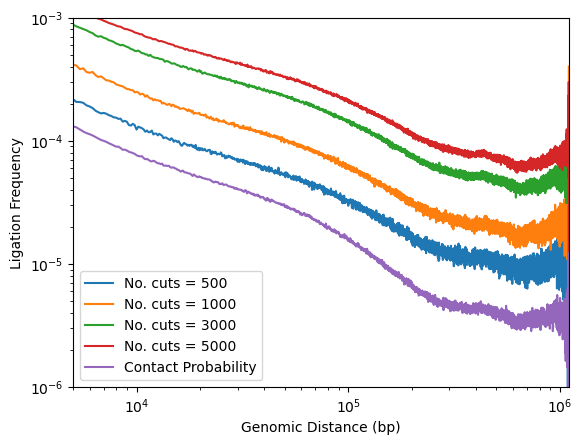

In [ ]:
#Ligation frequencies as a function of genomic distance for different digestion efficiencies and a ligation rate of p/p_0=1, and comparison with contact probability of the native ensemble of structures

plt.plot(scaled_xticks, lpg_d_500[0])
plt.plot(scaled_xticks, lpg_d_1000[0])
plt.plot(scaled_xticks, lpg_d_3000[0])
plt.plot(scaled_xticks, lpg_d_5000[0])

cuts_exp_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000) ,'No. cuts = '+str(5000), 'Experimental - 1Kbp', 'Contact Probability']
cuts_exp_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000) ,'No. cuts = '+str(5000), 'Contact Probability']


xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
#plt.plot(scaled_xticks_exp, normalize/200)

plt.plot(scaled_xticks, cpa_ens/10)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(cuts_exp_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Frequency')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-6,1e-3])
plt.xlim([5000,5500*200])
plt.show()

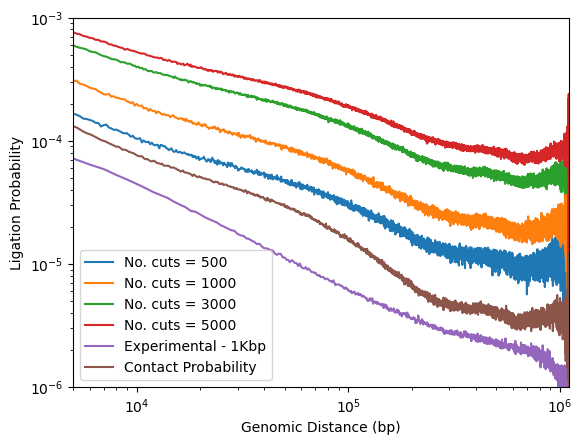

In [ ]:
#Ligation frequencies as a function of genomic distance for different digestion efficiencies and a ligation rate of p/p_0=0.1, 
#and comparison with both contact probability of the native ensemble of structures and experimental ligation probability

plt.plot(scaled_xticks, lpg_d_500[1])
plt.plot(scaled_xticks, lpg_d_1000[1])
plt.plot(scaled_xticks, lpg_d_3000[1])
plt.plot(scaled_xticks, lpg_d_5000[1])

cuts_exp_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000) ,'No. cuts = '+str(5000), 'Experimental - 1Kbp', 'Contact Probability']
                   
xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
plt.plot(scaled_xticks_exp, normalize/200)

plt.plot(scaled_xticks, cpa_ens/10)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(cuts_exp_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Probability')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-6,1e-3])
plt.xlim([5000,5500*200])
plt.show()

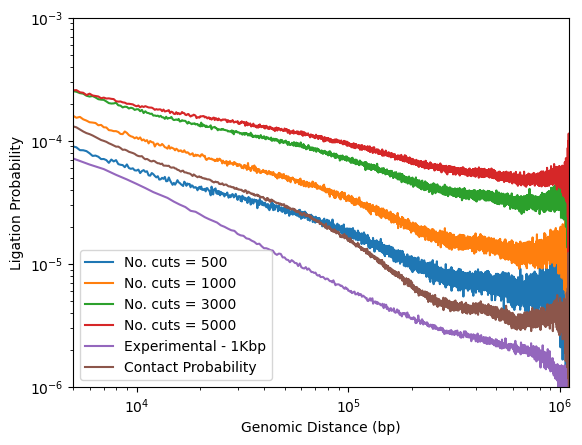

In [ ]:

#Ligation frequencies as a function of genomic distance for different digestion efficiencies and a ligation rate of p/p_0=0.01, 
#and comparison with both contact probability of the native ensemble of structures and experimental ligation probability

plt.plot(scaled_xticks, lpg_d_500[2])
plt.plot(scaled_xticks, lpg_d_1000[2])
plt.plot(scaled_xticks, lpg_d_3000[2])
plt.plot(scaled_xticks, lpg_d_5000[2])

cuts_exp_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000) ,'No. cuts = '+str(5000), 'Experimental - 1Kbp', 'Contact Probability']
                   
xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
plt.plot(scaled_xticks_exp, normalize/200)

plt.plot(scaled_xticks, cpa_ens/10)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(cuts_exp_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Probability')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-6,1e-3])
plt.xlim([5000,5500*200])
plt.show()

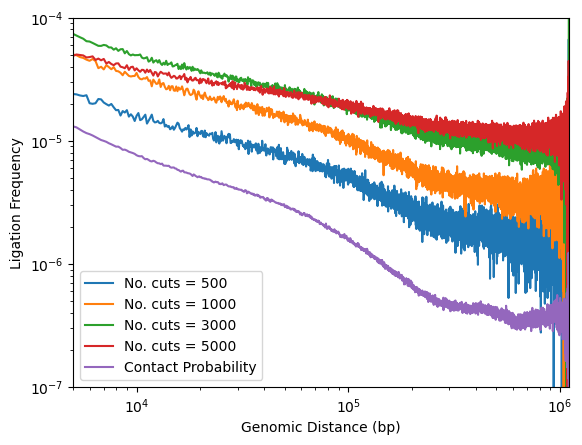

In [ ]:
#Ligation frequencies as a function of genomic distance for different digestion efficiencies and a ligation rate of p/p_0=0.001, 
#and comparison with both contact probability of the native ensemble of structures and experimental ligation probability

plt.plot(scaled_xticks, lpg_d_500[3])
plt.plot(scaled_xticks, lpg_d_1000[3])
plt.plot(scaled_xticks, lpg_d_3000[3])
plt.plot(scaled_xticks, lpg_d_5000[3])

cuts_exp_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000) ,'No. cuts = '+str(5000), 'Contact Probability']
                   
xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
#plt.plot(scaled_xticks_exp, normalize/200)

plt.plot(scaled_xticks, cpa_ens/100)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(cuts_exp_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Frequency')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-7,1e-4])
plt.xlim([5000,5500*200])
plt.show()

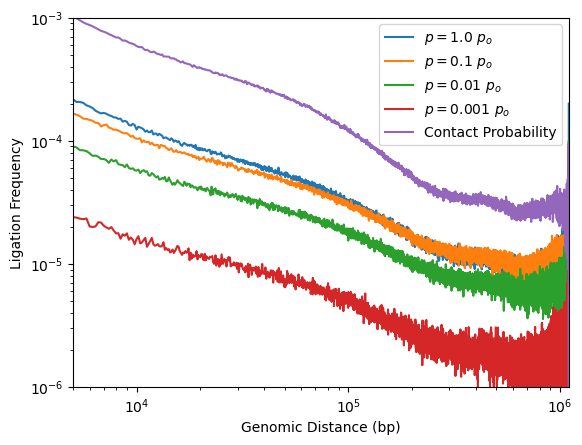

In [ ]:
#Ligation frequencies as a function of genomic distance for different ligation efficiencies and 500 bond cuts, 
#and comparison with both contact probability of the native ensemble of structures

plt.plot(scaled_xticks, lpg_d_500[0])
plt.plot(scaled_xticks, lpg_d_500[1])
plt.plot(scaled_xticks, lpg_d_500[2])
plt.plot(scaled_xticks, lpg_d_500[3])

po_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$', 'Contact Probability']

xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
#plt.plot(scaled_xticks_exp, normalize/100)

plt.plot(scaled_xticks, cpa_ens/1.3)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(po_legend,loc='upper right')
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Frequency')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-6,1e-3])
plt.xlim([5000,5500*200])
plt.show()

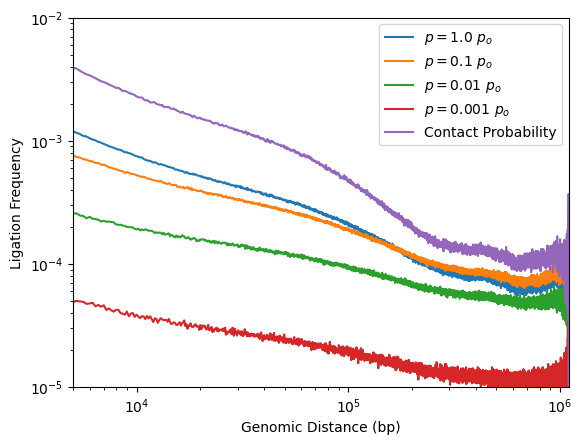

In [ ]:
#Ligation frequencies as a function of genomic distance for different ligation efficiencies and 5000 bond cuts, 
#and comparison with both contact probability of the native ensemble of structures

plt.plot(scaled_xticks, lpg_d_5000[0])
plt.plot(scaled_xticks, lpg_d_5000[1])
plt.plot(scaled_xticks, lpg_d_5000[2])
plt.plot(scaled_xticks, lpg_d_5000[3])

po_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$', 'Contact Probability']

xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
#plt.plot(scaled_xticks_exp, normalize/100)

plt.plot(scaled_xticks, cpa_ens*3)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(po_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Frequency')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-5,1e-2])
plt.xlim([5000,5500*200])
plt.show()

In [24]:
print(scaled_xticks[2999])

600109.0942160785


In [ ]:
#Fits of power-law scaling exponents for ligation probabilities as a function of genomic distance

from scipy.optimize import curve_fit

def power_fit(x, a, alpha):
    return a*x**alpha

#print(len(scaled_xticks), len(cont_prob_5500))

lower_bound = 100 #49
upper_bound = 2999 #499

params_0500 = []
params_1000 = []
params_3000 = []
params_5000 = []

slope_p1e0 = []
slope_p1e1 = []
slope_p1e2 = []
slope_p1e3 = []

params_exp,  covariance_exp  = curve_fit(f = power_fit, xdata = scaled_xticks_exp[2:99], ydata = normalize[2:99], maxfev=10000)

params_cprob,  covariance_cprob  = curve_fit(f = power_fit, xdata = scaled_xticks[2:99], ydata = cpa_ens[2:99], maxfev=10000)

for i in range(Nprobs):

    param_0500, covariance_0500 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_d_500[i][lower_bound:upper_bound], maxfev=10000)
    param_1000, covariance_1000 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_d_1000[i][lower_bound:upper_bound], maxfev=10000)
    param_3000, covariance_3000 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_d_3000[i][lower_bound:upper_bound], maxfev=10000)
    param_5000, covariance_5000 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_d_5000[i][lower_bound:upper_bound], maxfev=10000)

    params_0500.append(param_0500[1])
    params_1000.append(param_1000[1])
    params_3000.append(param_3000[1])
    params_5000.append(param_5000[1])
    
    #print(param_5000)
    
slope_p1e0 = np.abs([params_0500[0], params_1000[0], params_3000[0], params_5000[0]])
slope_p1e1 = np.abs([params_0500[1], params_1000[1], params_3000[1], params_5000[1]])
slope_p1e2 = np.abs([params_0500[2], params_1000[2], params_3000[2], params_5000[2]])
slope_p1e3 = np.abs([params_0500[3], params_1000[3], params_3000[3], params_5000[3]])
                
params_0500 = np.abs(params_0500)
params_1000 = np.abs(params_1000)
params_3000 = np.abs(params_3000)
params_5000 = np.abs(params_5000)  


    
x= scaled_xticks_exp[2:99]

print(params_exp)
print(params_cprob)
#plt.plot(x, power_fit(x, params_exp[0], params_exp[1]))

#x= scaled_xticks[14:499]
#plt.plot(x, power_fit(x, params_0500[0], params_0500[1]))
#plt.plot(x, power_fit(x, params_1000[0], params_1000[1]))
#plt.plot(x, power_fit(x, params_3000[0], params_3000[1]))
#plt.plot(x, power_fit(x, params_5000[0], params_5000[1]))



[ 8.46728259 -0.75351583]
[ 0.01423603 -0.30413253]


In [26]:
scaled_xticks[24]

5000.873044743544

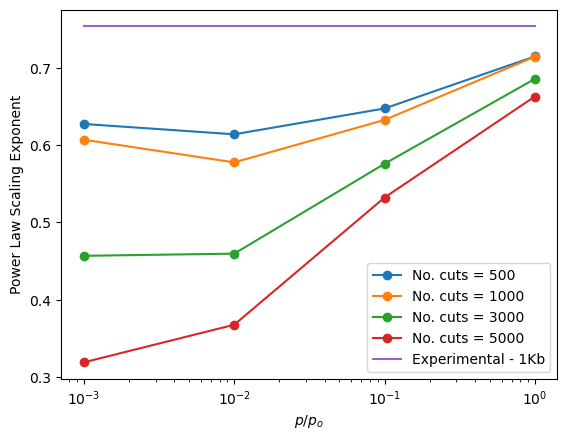

In [ ]:
#Power-law scaling exponent dependence of ligation probabilities as a function of ligation rate for different digestion efficiencies

p_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000),'No. cuts = '+str(5000), 'Experimental - 1Kb']

plt.plot(lig_probs, params_0500, marker = 'o')
plt.plot(lig_probs, params_1000, marker = 'o')
plt.plot(lig_probs, params_3000, marker = 'o')
plt.plot(lig_probs, params_5000, marker = 'o')

x = [1e-3, 1]
y = [abs(params_exp[1]),abs(params_exp[1])]

plt.plot(x, y)

plt.ylabel('Power Law Scaling Exponent')

plt.xlabel(r'$p/p_{o} $')

#plt.yscale("log")
plt.xscale("log")

plt.legend(p_legend)#loc='upper right')

plt.show()



In [30]:
print(len(ld_d_500), len(lpg_d_500[2]))

50 5499


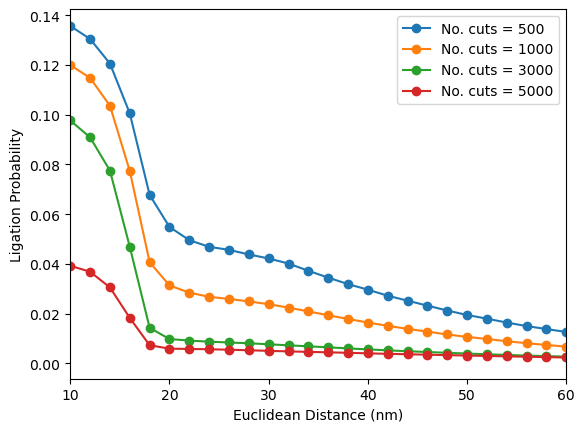

In [ ]:
#Ligation frequency as a function of Euclidean distance for different digestion efficiencies and a fixed ligation rate

plt.plot(10*ld_d_500[0:49],pl1_d_500[0], '-o')
plt.plot(10*ld_d_1000[0:49],pl1_d_1000[0], '-o')
plt.plot(10*ld_d_3000[0:49],pl1_d_3000[0], '-o')
plt.plot(10*ld_d_5000[0:49],pl1_d_5000[0], '-o')

#plt.plot(10*ld[0:49],pl1[5], '-o')
plt.legend(cuts_legend)
plt.xlim([10,60])
#plt.ylim([0,0.02])
#plt.yscale("log")
plt.xlabel('Euclidean Distance (nm)')
plt.ylabel('Ligation Probability')
plt.show()

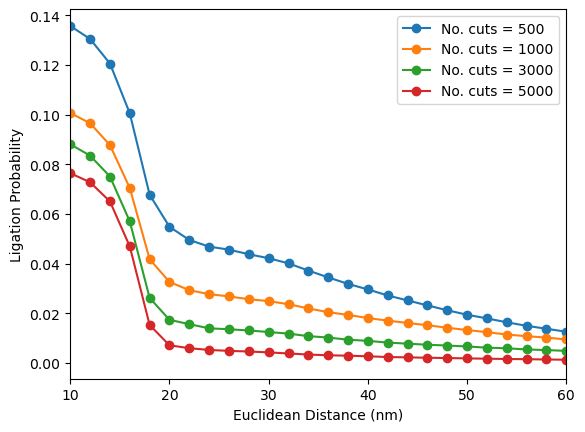

In [ ]:
#Ligation frequency as a function of Euclidean distance for different ligation efficiencies and fixed digestion efficiency

plt.plot(10*ld_d_500[0:49],pl1_d_500[0], '-o')
plt.plot(10*ld_d_500[0:49],pl1_d_500[1], '-o')
plt.plot(10*ld_d_500[0:49],pl1_d_500[2], '-o')
plt.plot(10*ld_d_500[0:49],pl1_d_500[3], '-o')

#plt.plot(10*ld[0:49],pl1[5], '-o')
plt.legend(p_legend)
plt.xlim([10,60])
#plt.ylim([0,0.02])
#plt.yscale("log")
plt.xlabel('Euclidean Distance (nm)')
plt.ylabel('Ligation Probability')
plt.show()

In [ ]:
#This cell defines the Knight-Ruiz normalization function for map normalization

import numpy as np

# Do KnightRuiz normalize
# input raw matrix
# output normalize matrix, minvalue, maxvalue
def NormalizeKnightRuizV2(matrix, tol=1e-12, x0=None, delta=0.1, Delta=3, fl=0):
    ''' Knight-Ruiz algorithm for matrix balancing
    This code is from Rajendra,K. et al. (2017) Genome contact map explorer: a platform for the comparison,
    interactive visualization and analysis of genome contact maps. Nucleic Acids Research, 45(17):e152.
    '''

    bNoData = np.all(matrix == 0.0, axis=0)
    bNonZeros = ~bNoData
    A = (matrix[bNonZeros, :])[:, bNonZeros]  # Selected row-column which are not all zeros
    # perform KR methods
    n = A.shape[0]  # n = size(A,1)
    e = np.ones((n, 1))  # e = ones(n,1)
    res = []
    if x0 is None:
        x0 = e

    g = 0.9  # Parameters used in inner stopping criterion.
    etamax = 0.1  # Parameters used in inner stopping criterion.
    eta = etamax
    stop_tol = tol * 0.5
    x = x0
    rt = tol ** 2  # rt = tol^2
    v = x * A.dot(x)  # v = x.*(A*x)
    rk = 1 - v
    rho_km1 = np.dot(rk.conjugate().T, rk)  # rho_km1 = rk'*rk
    rout = rho_km1
    rold = rout

    # x, x0, e, v, rk, y, Z, w, p, ap :     vector shape(n, 1) : [ [value] [value] [value] [value] ... ... ... [value] ]
    # rho_km1, rout, rold, innertol, alpha :  scalar shape(1 ,1) : [[value]]

    MVP = 0  # count matrix vector products.
    i = 0  # Outer iteration count.

    if fl == 1:
        print('it in. it res')

    while rout > rt:  # Outer iteration
        i = i + 1
        k = 0
        y = e
        innertol = max([eta ** 2 * rout, rt])  # innertol = max([eta^2*rout,rt]);

        while rho_km1 > innertol:  # Inner iteration by CG
            k = k + 1
            if k == 1:
                Z = rk / v  # Z = rk./v
                p = Z
                rho_km1 = np.dot(rk.conjugate().T, Z)  # rho_km1 = rk'*Z
            else:
                beta = rho_km1 / rho_km2
                p = Z + (beta * p)

            # Update search direction efficiently.
            w = x * A.dot((x * p)) + (v * p)  # w = x.*(A*(x.*p)) + v.*p
            alpha = rho_km1 / np.dot(p.conjugate().T, w)  # alpha = rho_km1/(p'*w)
            ap = alpha * p  # ap = alpha*p (No dot function as alpha is scalar)

            # Test distance to boundary of cone.
            ynew = y + ap;
            # print(i, np.amin(ynew), delta, np.amin(ynew) <= delta)
            # print(i, np.amax(ynew), Delta, np.amax(ynew) >= Delta)
            if np.amin(ynew) <= delta:
                if delta == 0:
                    break
                ind = np.nonzero(ap < 0)  # ind = find(ap < 0)
                gamma = np.amin((delta - y[ind]) / ap[ind])  # gamma = min((delta - y(ind))./ap(ind))
                y = y + np.dot(gamma, ap)  # y = y + gamma*ap
                break
            if np.amax(ynew) >= Delta:
                ind = np.nonzero(ynew > Delta)  # ind = find(ynew > Delta);
                gamma = np.amin((Delta - y[ind]) / ap[ind])  # gamma = min((Delta-y(ind))./ap(ind));
                y = y + np.dot(gamma, ap)  # y = y + gamma*ap;
                break
            y = ynew
            rk = rk - alpha * w  # rk = rk - alpha*w
            rho_km2 = rho_km1
            Z = rk / v
            rho_km1 = np.dot(rk.conjugate().T, Z)  # rho_km1 = rk'*Z

        x = x * y  # x = x.*y
        v = x * A.dot(x)  # v = x.*(A*x)
        rk = 1 - v
        rho_km1 = np.dot(rk.conjugate().T, rk)  # rho_km1 = rk'*rk
        rout = rho_km1
        MVP = MVP + k + 1

        # Update inner iteration stopping criterion.
        rat = rout / rold
        rold = rout
        res_norm = np.sqrt(rout)
        eta_o = eta
        eta = g * rat

        # print(i, res_norm)

        if g * eta_o ** 2 > 0.1:
            eta = np.amax([eta, g * eta_o ** 2])  # eta = max([eta,g*eta_o^2])

        eta = np.amax(
            [np.amin([eta, etamax]), stop_tol / res_norm]);  # eta = max([min([eta,etamax]),stop_tol/res_norm]);

        if fl == 1:
            print('%3d %6d %.3e %.3e %.3e \n' % (i, k, res_norm, np.amin(y), np.amin(x)))
            res = [res, res_norm]

    # Generation of Doubly stochastic matrix ( diag(X)*A*diag(X) )
    outA = x.T * (A * x)

    normMat = np.zeros(matrix.shape)  # all 0 init matrix

    # Store normalized values to output matrix
    dsm_i = 0
    ox = normMat.shape[0]
    idx_fill = np.nonzero(~bNoData)
    for i in range(ox):
        if not bNoData[i]:
            normMat[i, idx_fill] = outA[dsm_i]
            normMat[idx_fill, i] = outA[dsm_i]
            dsm_i += 1

    # Get the maximum and minimum value except zero
    ma = np.ma.masked_equal(outA, 0.0, copy=False)
    n_min = ma.min()
    n_max = ma.max()

    return normMat, n_min, n_max

In [27]:
import copy

#Calculation of KR-normalized matrices and KR-normalized ligation probabilities for different numbers of cuts and ligation rates

KR_normalized_matrix_d_500 = []
KR_normalized_matrix_d_1000 = []
KR_normalized_matrix_d_3000 = []
KR_normalized_matrix_d_5000 = []

Non_normalized_matrix_d_500 = []
Non_normalized_matrix_d_1000 = []
Non_normalized_matrix_d_3000 = []
Non_normalized_matrix_d_5000 = []

KR_lig_prob_average_d_500 = []
KR_lig_prob_average_d_1000 = []
KR_lig_prob_average_d_3000 = []
KR_lig_prob_average_d_5000 = []

Non_lig_prob_average_d_500 = []
Non_lig_prob_average_d_1000 = []
Non_lig_prob_average_d_3000 = []
Non_lig_prob_average_d_5000 = []

lmin = 1
lmax = 5499

dmax = 5500
init = 1

for i in range(len(lig_probs)):

    #500 cuts
    symm = lmgn_d_500[i] + np.transpose(lmgn_d_500[i]) - np.diag(np.diag(lmgn_d_500[i]))
    normalized_matrix, n_min, n_max = NormalizeKnightRuizV2(symm[lmin:lmax,lmin:lmax], tol=1e-12, x0=None, delta=0.2, Delta=3, fl=0)
    #print(np.sum(normalized_matrix, axis=0))
    
    Non_normalized_matrix_d_500.append(copy.deepcopy(symm[lmin:lmax,lmin:lmax]))
    KR_normalized_matrix_d_500.append(copy.deepcopy(normalized_matrix))
    
    Non_lig_prob_average = np.zeros(dmax)
    for j in range(dmax):
        Non_lig_prob_average[j] =  np.mean(np.diagonal(symm[lmin:lmax,lmin:lmax], offset=(j+init)))
        
    KR_lig_prob_average = np.zeros(dmax)
    for j in range(dmax):
        KR_lig_prob_average[j] =  np.mean(np.diagonal(normalized_matrix, offset=(j+init)))
    
    Non_lig_prob_average_d_500.append(copy.deepcopy(Non_lig_prob_average))
    KR_lig_prob_average_d_500.append(copy.deepcopy(KR_lig_prob_average))
    
    ###################################################################
    
    #1000 cuts
    symm = lmgn_d_1000[i] + np.transpose(lmgn_d_1000[i]) - np.diag(np.diag(lmgn_d_1000[i]))
    normalized_matrix, n_min, n_max = NormalizeKnightRuizV2(symm[lmin:lmax,lmin:lmax], tol=1e-12, x0=None, delta=0.2, Delta=3, fl=0)
    #print(np.sum(normalized_matrix, axis=0))

    Non_normalized_matrix_d_1000.append(copy.deepcopy(symm[lmin:lmax,lmin:lmax]))
    KR_normalized_matrix_d_1000.append(copy.deepcopy(normalized_matrix))
    
    Non_lig_prob_average = np.zeros(dmax)
    for j in range(dmax):
        Non_lig_prob_average[j] =  np.mean(np.diagonal(symm[lmin:lmax,lmin:lmax], offset=(j+init)))
        
    KR_lig_prob_average = np.zeros(dmax)
    for j in range(dmax):
        KR_lig_prob_average[j] =  np.mean(np.diagonal(normalized_matrix, offset=(j+init)))
    
    Non_lig_prob_average_d_1000.append(copy.deepcopy(Non_lig_prob_average))
    KR_lig_prob_average_d_1000.append(copy.deepcopy(KR_lig_prob_average))
    
    ###################################################################
    
    #3000 cuts
    symm = lmgn_d_3000[i] + np.transpose(lmgn_d_3000[i]) - np.diag(np.diag(lmgn_d_3000[i]))
    normalized_matrix, n_min, n_max = NormalizeKnightRuizV2(symm[lmin:lmax,lmin:lmax], tol=1e-12, x0=None, delta=0.2, Delta=3, fl=0)
    #print(np.sum(normalized_matrix, axis=0))

    Non_normalized_matrix_d_3000.append(copy.deepcopy(symm[lmin:lmax,lmin:lmax]))
    KR_normalized_matrix_d_3000.append(copy.deepcopy(normalized_matrix))
    
    Non_lig_prob_average = np.zeros(dmax)
    for j in range(dmax):
        Non_lig_prob_average[j] =  np.mean(np.diagonal(symm[lmin:lmax,lmin:lmax], offset=(j+init)))
        
    KR_lig_prob_average = np.zeros(dmax)
    for j in range(dmax):
        KR_lig_prob_average[j] =  np.mean(np.diagonal(normalized_matrix, offset=(j+init)))
 
    Non_lig_prob_average_d_3000.append(copy.deepcopy(Non_lig_prob_average))
    KR_lig_prob_average_d_3000.append(copy.deepcopy(KR_lig_prob_average))
    
    ###################################################################
    
    #5000 cuts
    symm = lmgn_d_5000[i] + np.transpose(lmgn_d_5000[i]) - np.diag(np.diag(lmgn_d_5000[i]))
    normalized_matrix, n_min, n_max = NormalizeKnightRuizV2(symm[lmin:lmax,lmin:lmax], tol=1e-12, x0=None, delta=0.2, Delta=3, fl=0)
    #print(np.sum(normalized_matrix, axis=0))

    Non_normalized_matrix_d_5000.append(copy.deepcopy(symm[lmin:lmax,lmin:lmax]))
    KR_normalized_matrix_d_5000.append(copy.deepcopy(normalized_matrix))
    
    Non_lig_prob_average = np.zeros(dmax)
    for j in range(dmax):
        Non_lig_prob_average[j] =  np.mean(np.diagonal(symm[lmin:lmax,lmin:lmax], offset=(j+init)))
        
    KR_lig_prob_average = np.zeros(dmax)
    for j in range(dmax):
        KR_lig_prob_average[j] =  np.mean(np.diagonal(normalized_matrix, offset=(j+init)))
  
    Non_lig_prob_average_d_5000.append(copy.deepcopy(Non_lig_prob_average))
    KR_lig_prob_average_d_5000.append(copy.deepcopy(KR_lig_prob_average))

In [48]:
ps = [1, 0.1, 0.01, 0.001]
print('p', 500, 1000, 3000, 5000)
for m in range(4):
    print(ps[m], np.sum(lmgn_d_500[m]), np.sum(lmgn_d_1000[m]), np.sum(lmgn_d_3000[m]), np.sum(lmgn_d_5000[m]))

p 500 1000 3000 5000
1 451.82099999999997 873.2842000000032 2126.103999999998 2660.7964000000075
0.1 395.33500000000026 776.6191999999986 1915.4632000000029 2362.505000000003
0.01 248.21039999999957 515.2292000000006 1317.9474000000023 1381.145200000002
0.001 97.37159999999994 250.75400000000053 834.583 585.8446000000001


In [49]:
#Distributions of column sums for non-normalized matrices

histo_lmgn_d_500 = []
histo_lmgn_d_1000 = []
histo_lmgn_d_3000 = []
histo_lmgn_d_5000 = []

for i in range(len(lig_probs)):
    histo_lmgn_d_500.append(copy.deepcopy(np.histogram(np.sum(Non_normalized_matrix_d_500[i], axis=0), bins=25, range=None, density=None, weights=None)))
    histo_lmgn_d_1000.append(copy.deepcopy(np.histogram(np.sum(Non_normalized_matrix_d_1000[i], axis=0), bins=25, range=None, density=None, weights=None)))
    histo_lmgn_d_3000.append(copy.deepcopy(np.histogram(np.sum(Non_normalized_matrix_d_3000[i], axis=0), bins=25, range=None, density=None, weights=None)))
    histo_lmgn_d_5000.append(copy.deepcopy(np.histogram(np.sum(Non_normalized_matrix_d_5000[i], axis=0), bins=25, range=None, density=None, weights=None)))

In [28]:
#Non-normalized maps rescaled to have same average total column sum as KR normalized maps for comparison between them

Rescale_non_normalized_d_500  = []
Rescale_non_normalized_d_1000 = []
Rescale_non_normalized_d_3000 = []
Rescale_non_normalized_d_5000 = []

for m in range(len(lig_probs)):
    Rescale_non_normalized_d_500.append(Non_normalized_matrix_d_500[m]/np.average(np.sum(Non_normalized_matrix_d_500[m], axis=1)))
    Rescale_non_normalized_d_1000.append(Non_normalized_matrix_d_1000[m]/np.average(np.sum(Non_normalized_matrix_d_1000[m], axis=1)))
    Rescale_non_normalized_d_3000.append(Non_normalized_matrix_d_3000[m]/np.average(np.sum(Non_normalized_matrix_d_3000[m], axis=1)))
    Rescale_non_normalized_d_5000.append(Non_normalized_matrix_d_5000[m]/np.average(np.sum(Non_normalized_matrix_d_5000[m], axis=1)))

In [421]:
#Write Normalized and Unnormalized maps
for i in range(len(lig_probs)):
    np.savetxt('Diff_matrix_d_500_mp_'+str(i)+'.csv',  KR_normalized_matrix_d_500[i]-Rescale_non_normalized_d_500[i], delimiter=" ")
    np.savetxt('Diff_matrix_d_1000_mp_'+str(i)+'.csv', KR_normalized_matrix_d_1000[i]-Rescale_non_normalized_d_1000[i], delimiter=" ")
    np.savetxt('Diff_matrix_d_3000_mp_'+str(i)+'.csv', KR_normalized_matrix_d_3000[i]-Rescale_non_normalized_d_3000[i], delimiter=" ")
    np.savetxt('Diff_matrix_d_5000_mp_'+str(i)+'.csv', KR_normalized_matrix_d_5000[i]-Rescale_non_normalized_d_5000[i], delimiter=" ")

    np.savetxt('Ratio_matrix_d_500_mp_'+str(i)+'.csv',  np.divide(KR_normalized_matrix_d_500[i],Rescale_non_normalized_d_500[i]), delimiter=" ")
    np.savetxt('Ratio_matrix_d_1000_mp_'+str(i)+'.csv', np.divide(KR_normalized_matrix_d_1000[i],Rescale_non_normalized_d_1000[i]), delimiter=" ")
    np.savetxt('Ratio_matrix_d_3000_mp_'+str(i)+'.csv', np.divide(KR_normalized_matrix_d_3000[i],Rescale_non_normalized_d_3000[i]), delimiter=" ")
    np.savetxt('Ratio_matrix_d_5000_mp_'+str(i)+'.csv', np.divide(KR_normalized_matrix_d_5000[i],Rescale_non_normalized_d_5000[i]), delimiter=" ")
    
    np.savetxt('KR_normalized_matrix_d_500_mp_'+str(i)+'.csv',  KR_normalized_matrix_d_500[i], delimiter=" ")
    np.savetxt('KR_normalized_matrix_d_1000_mp_'+str(i)+'.csv', KR_normalized_matrix_d_1000[i], delimiter=" ")
    np.savetxt('KR_normalized_matrix_d_3000_mp_'+str(i)+'.csv', KR_normalized_matrix_d_3000[i], delimiter=" ")
    np.savetxt('KR_normalized_matrix_d_5000_mp_'+str(i)+'.csv', KR_normalized_matrix_d_5000[i], delimiter=" ")
    
    np.savetxt('Non_normalized_matrix_d_500_mp_'+str(i)+'.csv',  Rescale_non_normalized_d_500[i], delimiter=" ")
    np.savetxt('Non_normalized_matrix_d_1000_mp_'+str(i)+'.csv', Rescale_non_normalized_d_1000[i], delimiter=" ")
    np.savetxt('Non_normalized_matrix_d_3000_mp_'+str(i)+'.csv', Rescale_non_normalized_d_3000[i], delimiter=" ")
    np.savetxt('Non_normalized_matrix_d_5000_mp_'+str(i)+'.csv', Rescale_non_normalized_d_5000[i], delimiter=" ")
    
np.savetxt('Diff_Ave_Cont_Map'+str(i)+'.csv', KR_normalized_ave_cont_map - Rescale_non_normalized_ave_cont_map, delimiter='')
np.savetxt('Ratio_Ave_Cont_Map'+str(i)+'.csv', np.divide(KR_normalized_ave_cont_map, Rescale_non_normalized_ave_cont_map), delimiter='')
np.savetxt('KR_normalized_Ave_Cont_Map'+str(i)+'.csv', KR_normalized_ave_cont_map, delimiter='')
np.savetxt('Non_normalized_Ave_Cont_Map'+str(i)+'.csv', Rescale_non_normalized_ave_cont_map, delimiter='')


'\n#Write Normalized and Unnormalized maps\nfor i in range(len(lig_probs)):\n    np.savetxt(\'KR_normalized_matrix_d_500_mp_\'+str(i)+\'.csv\',  KR_normalized_matrix_d_500[i], delimiter=" ")\n    np.savetxt(\'KR_normalized_matrix_d_1000_mp_\'+str(i)+\'.csv\', KR_normalized_matrix_d_1000[i], delimiter=" ")\n    np.savetxt(\'KR_normalized_matrix_d_3000_mp_\'+str(i)+\'.csv\', KR_normalized_matrix_d_3000[i], delimiter=" ")\n    np.savetxt(\'KR_normalized_matrix_d_5000_mp_\'+str(i)+\'.csv\', KR_normalized_matrix_d_5000[i], delimiter=" ")\n    \n    np.savetxt(\'Non_normalized_matrix_d_500_mp_\'+str(i)+\'.csv\',  Rescale_non_normalized_matrix_d_500[i], delimiter=" ")\n    np.savetxt(\'Non_normalized_matrix_d_1000_mp_\'+str(i)+\'.csv\', Rescale_non_normalized_matrix_d_1000[i], delimiter=" ")\n    np.savetxt(\'Non_normalized_matrix_d_3000_mp_\'+str(i)+\'.csv\', Rescale_non_normalized_matrix_d_3000[i], delimiter=" ")\n    np.savetxt(\'Non_normalized_matrix_d_5000_mp_\'+str(i)+\'.csv\', Rescale_

In [51]:
#Differences and Ratios of Normalized and Unnormalized maps

Diff_matrix_d_500  = []
Diff_matrix_d_1000 = []
Diff_matrix_d_3000 = []
Diff_matrix_d_5000 = []

Ratio_matrix_d_500  = []
Ratio_matrix_d_1000 = []
Ratio_matrix_d_3000 = []
Ratio_matrix_d_5000 = []

for i in range(len(lig_probs)):
    Diff_matrix_d_500.append(KR_normalized_matrix_d_500[i]-Rescale_non_normalized_d_500[i])
    Diff_matrix_d_1000.append(KR_normalized_matrix_d_1000[i]-Rescale_non_normalized_d_1000[i])
    Diff_matrix_d_3000.append(KR_normalized_matrix_d_3000[i]-Rescale_non_normalized_d_3000[i])
    Diff_matrix_d_5000.append(KR_normalized_matrix_d_5000[i]-Rescale_non_normalized_d_5000[i])

    Ratio_matrix_d_500.append(np.divide(KR_normalized_matrix_d_500[i],Rescale_non_normalized_d_500[i]))
    Ratio_matrix_d_1000.append(np.divide(KR_normalized_matrix_d_1000[i],Rescale_non_normalized_d_1000[i]))
    Ratio_matrix_d_3000.append(np.divide(KR_normalized_matrix_d_3000[i],Rescale_non_normalized_d_3000[i]))
    Ratio_matrix_d_5000.append(np.divide(KR_normalized_matrix_d_5000[i],Rescale_non_normalized_d_5000[i]))
    
Diff_Ave_Cont_Map = KR_normalized_ave_cont_map - Rescale_non_normalized_ave_cont_map
Ratio_Ave_Cont_Map = np.divide(KR_normalized_ave_cont_map, Rescale_non_normalized_ave_cont_map)

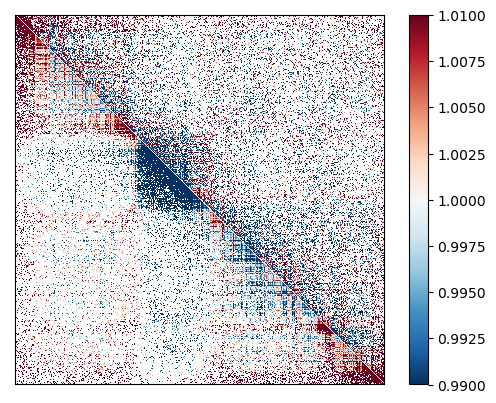

In [52]:
#Half and half matrix split along the diagonal.
#The upper triangle corresponds to the KR-Norm/Non-Norm ratio for the ligation map.
#The upper triangle corresponds to the KR-Norm/Non-Norm ratio for the average contact map.

Ratio_Triangle_Matrix = np.triu(Ratio_matrix_d_3000[1])
Ratio_Triangle_Matrix += np.tril(Ratio_Ave_Cont_Map)

fig = plt.figure()
ax = fig.add_subplot(111)
c_map = plt.cm.get_cmap('RdBu') 
c_map = c_map.reversed()
cax = ax.matshow(Ratio_Triangle_Matrix,vmin=0.99, vmax=1.01, cmap=c_map) #,cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]),vmin=0.5, vmax=1.5, interpolation='nearest')
fig.colorbar(cax)

#ax.set_title('KR-Norm. / Non-Norm. Ratio')
ax.set_xticks([])
ax.set_yticks([])

plt.show()

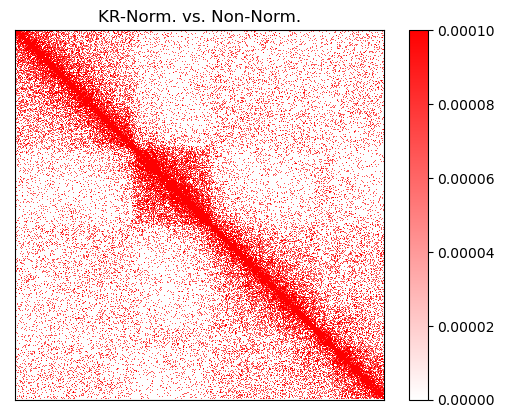

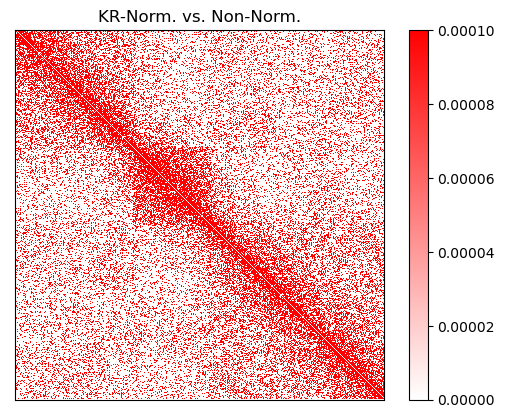

In [ ]:
#Half and half matrix split along the diagonal.
#Upper triangule: Non KR normalized. 
#Lower triangle: KR-normalized.
#For Average Contact Map.

Split_AveContMap  = np.triu(Rescale_non_normalized_ave_cont_map)
Split_AveContMap += np.tril(KR_normalized_ave_cont_map)

fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(Split_AveContMap,cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]),vmin=0, vmax=1e-4, interpolation='nearest')
fig.colorbar(cax)

ax.set_title('KR-Norm. vs. Non-Norm.')
ax.set_xticks([])
ax.set_yticks([])

plt.show()

#For Ligation Map.

Split_LigationMap_d_500 = []
Split_LigationMap_d_1000 = []
Split_LigationMap_d_3000 = []
Split_LigationMap_d_5000 = []

for i in range(len(lig_probs)):
    
    Split_LigMap  = np.triu(Rescale_non_normalized_d_500[i])
    Split_LigMap += np.tril(KR_normalized_matrix_d_500[i])
    
    Split_LigationMap_d_500.append(Split_LigMap)
    
    Split_LigMap  = np.triu(Rescale_non_normalized_d_1000[i])
    Split_LigMap += np.tril(KR_normalized_matrix_d_1000[i])
    
    Split_LigationMap_d_1000.append(Split_LigMap)
    
    Split_LigMap  = np.triu(Rescale_non_normalized_d_3000[i])
    Split_LigMap += np.tril(KR_normalized_matrix_d_3000[i])
    
    Split_LigationMap_d_3000.append(Split_LigMap)
    
    Split_LigMap  = np.triu(Rescale_non_normalized_d_5000[i])
    Split_LigMap += np.tril(KR_normalized_matrix_d_5000[i])
    
    Split_LigationMap_d_5000.append(Split_LigMap)

fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(Split_LigationMap_d_3000[1],cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]),vmin=0, vmax=1e-4, interpolation='nearest')
fig.colorbar(cax)

ax.set_title('KR-Norm. vs. Non-Norm.')
ax.set_xticks([])
ax.set_yticks([])

plt.show()

In [161]:
#Write Normalized and Unnormalized maps
for i in range(len(lig_probs)):
    np.savetxt('Split_matrix_d_500_mp_'+str(i)+'.csv',  Split_LigationMap_d_500[i], delimiter=" ")
    np.savetxt('Split_matrix_d_1000_mp_'+str(i)+'.csv', Split_LigationMap_d_1000[i], delimiter=" ")
    np.savetxt('Split_matrix_d_3000_mp_'+str(i)+'.csv', Split_LigationMap_d_3000[i], delimiter=" ")
    np.savetxt('Split_matrix_d_5000_mp_'+str(i)+'.csv', Split_LigationMap_d_5000[i], delimiter=" ")

np.savetxt('Split_matrix_AveContMap.csv', Split_AveContMap, delimiter=" ")


In [31]:
#Calculation of KR-normalized matrices and KR-normalized ligation probabilities for original average contact map of underlying native structures

lmin = 1
lmax = 5499

dmax = 5500
init = 1

Non_normalized_ave_cont_map = cma_ens[lmin:lmax,lmin:lmax]
KR_normalized_ave_cont_map, n_min, n_max = NormalizeKnightRuizV2(Non_normalized_ave_cont_map, tol=1e-12, x0=None, delta=0.2, Delta=3, fl=0)
    
Non_lig_prob_ave_cont_map = np.zeros(dmax)
for j in range(dmax):
    Non_lig_prob_average[j] =  np.mean(np.diagonal(Non_normalized_ave_cont_map, offset=(j+init)))

KR_lig_prob_ave_cont_map = np.zeros(dmax)
for j in range(dmax):
    KR_lig_prob_average[j] =  np.mean(np.diagonal(KR_normalized_ave_cont_map, offset=(j+init)))
    
    
Rescale_non_normalized_ave_cont_map=Non_normalized_ave_cont_map/np.average(np.sum(Non_normalized_ave_cont_map , axis=1))
    
#plt.plot(np.sum(Non_normalized_ave_cont_map, axis=0))
#plt.plot(np.sum(KR_normalized_ave_cont_map, axis=0))
#plt.plot(np.sum(Non_normalized_ave_cont_map, axis=1))
#plt.plot(np.sum(KR_normalized_ave_cont_map, axis=1))

In [55]:
#Calculation of KR-normalized matrices and ligation probabilities for time evolved, x-linked and chopped structures
#At different times during the time evolution of the system


#Pick snapshots or time slices for calculation of KR normalization of evolved contact maps

chosen_snapshots = [0, 10, 100, 1000]
snap_index = []
for i in chosen_snapshots:
    snap_index.append(np.where(iframes_e_5000==i)[0][0])
    
print(snap_index)

#KR-normalization of time-evolved contact maps for chosen snapshots

lmin = 1
lmax = 5499

dmax = 5500
init = 1


#For 500 cuts
KR_normalized_ave_cont_map_e_500 = []
Rescale_non_normalized_ave_cont_map_e_500 = []

for i in snap_index:
    print('chosen snapshot / time slice ', iframes_e_500[i], 'array index',  i)
    
    Non_normalized_ave_cont_map_e = contact_map_average_e_500[i][lmin:lmax,lmin:lmax]
    KR_normalized_ave_cont_map_e, n_min, n_max = NormalizeKnightRuizV2(Non_normalized_ave_cont_map_e, tol=1e-12, x0=None, delta=0.2, Delta=3, fl=0)
    Rescale_non_normalized_ave_cont_map_e=Non_normalized_ave_cont_map_e/np.average(np.sum(Non_normalized_ave_cont_map_e , axis=1))
    
    KR_normalized_ave_cont_map_e_500.append(KR_normalized_ave_cont_map_e)
    Rescale_non_normalized_ave_cont_map_e_500.append(Rescale_non_normalized_ave_cont_map_e)

#For 5000 cuts
KR_normalized_ave_cont_map_e_5000 = []
Rescale_non_normalized_ave_cont_map_e_5000 = []

for i in snap_index:
    print('chosen snapshot / time slice ', iframes_e_5000[i], 'array index',  i)
    
    Non_normalized_ave_cont_map_e = contact_map_average_e_5000[i][lmin:lmax,lmin:lmax]
    KR_normalized_ave_cont_map_e, n_min, n_max = NormalizeKnightRuizV2(Non_normalized_ave_cont_map_e, tol=1e-12, x0=None, delta=0.2, Delta=3, fl=0)
    Rescale_non_normalized_ave_cont_map_e=Non_normalized_ave_cont_map_e/np.average(np.sum(Non_normalized_ave_cont_map_e , axis=1))
    
    KR_normalized_ave_cont_map_e_5000.append(KR_normalized_ave_cont_map_e)
    Rescale_non_normalized_ave_cont_map_e_5000.append(Rescale_non_normalized_ave_cont_map_e)
    

[0, 10, 19, 23]
chosen snapshot / time slice  0 array index 0
chosen snapshot / time slice  10 array index 10
chosen snapshot / time slice  100 array index 19
chosen snapshot / time slice  1000 array index 23
chosen snapshot / time slice  0 array index 0
chosen snapshot / time slice  10 array index 10
chosen snapshot / time slice  100 array index 19
chosen snapshot / time slice  1000 array index 23


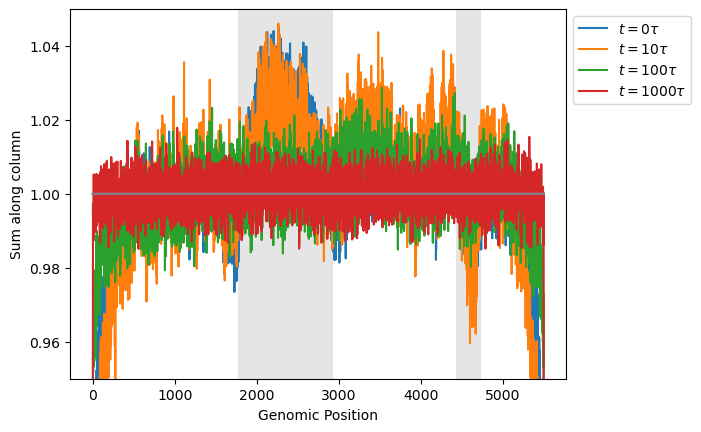

In [56]:
#Sum of columns along the chromosome for rescaled non-normalized contact maps

for i in range(len(chosen_snapshots)):
    p_e_legend = [r'$t = $'+str(0)+r'$ \tau$',r'$t = $'+str(10)+r'$ \tau$',r'$t = $'+str(100)+r'$ \tau$',r'$t = $'+str(1000)+r'$ \tau$']
    plt.plot(np.sum(Rescale_non_normalized_ave_cont_map_e_5000[i], axis=0))
    plt.xlabel('Genomic Position')
    plt.ylabel('Sum along column')    
#plt.plot(np.sum(Rescale_non_normalized_ave_cont_map, axis=0))

for i in range(len(chosen_snapshots)):
    plt.plot(np.sum(KR_normalized_ave_cont_map_e_5000[i], axis=0))


plt.axvspan(1775, 2924, color='gray', alpha=0.2, lw=0)
plt.axvspan(4424, 4735, color='gray', alpha=0.2, lw=0)

plt.ylim([0.95,1.05])

plt.legend(p_e_legend,  bbox_to_anchor=(1, 1))

Text(0.5, 0, 'Genomic Position (bp)')

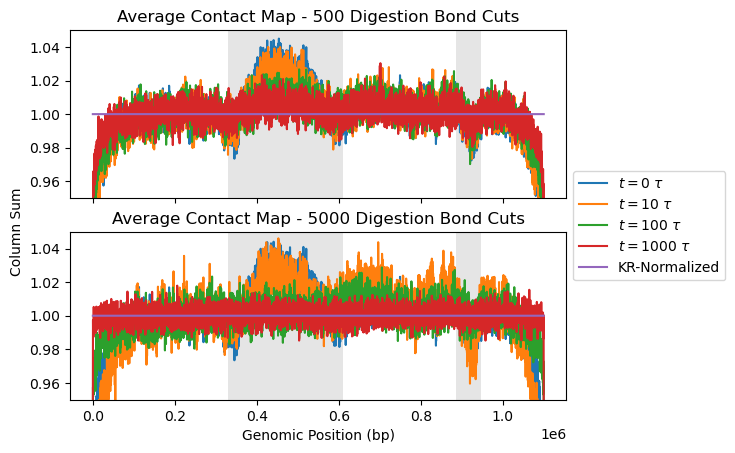

In [57]:
import matplotlib.ticker as mticker


fig, axs = plt.subplots(2, sharex=True, sharey=True)

#fig.suptitle('Sums of columns along genomic position', x= 1, y=2.1)


xscale=np.linspace(0,5497,num=5498,dtype=int)

for i in range(len(chosen_snapshots)):
    axs[0].plot(200*xscale, np.sum(Rescale_non_normalized_ave_cont_map_e_500[i], axis=0))
    #axs[0].plot(200*xscale[0:5499], MovAve_Rescale_Ave_Cont[0:-1])
    axs[0].set_title('Average Contact Map - 500 Digestion Bond Cuts')
    axs[0].set_ylabel('')
    axs[0].set_ylim([0.95,1.05])
    axs[1].plot(200*xscale, np.sum(Rescale_non_normalized_ave_cont_map_e_5000[i], axis=0))
    #axs[1].plot(200*xscale, MA_Non_normalized_matrix_d_5000[2][0:-1]/np.average(MA_Non_normalized_matrix_d_500[2][0:-1]))
    axs[1].set_title('Average Contact Map - 5000 Digestion Bond Cuts')
    axs[1].set_ylim([0.95,1.05])
axs[0].plot(200*xscale, np.sum(KR_normalized_ave_cont_map_e_500[0], axis=0))
axs[1].plot(200*xscale, np.sum(KR_normalized_ave_cont_map_e_5000[0], axis=0))
axs[0].axvspan(200*1650, 200*3050, color='gray', alpha=0.2, lw=0)
axs[0].axvspan(200*4424, 200*4735, color='gray', alpha=0.2, lw=0)
axs[1].axvspan(200*1650, 200*3050, color='gray', alpha=0.2, lw=0)
axs[1].axvspan(200*4424, 200*4735, color='gray', alpha=0.2, lw=0)

t_e_legend = [r'$t = $'+str(0)+r' $\tau$',r'$t = $'+str(10)+r' $ \tau$',r'$t = $'+str(100)+r' $ \tau$',r'$t = $'+str(1000)+r' $ \tau$', 'KR-Normalized']
axs[0].legend(t_e_legend, bbox_to_anchor=(1, .2))

plt.ylabel("Column Sum", y = 1)
plt.xlabel("Genomic Position (bp)")

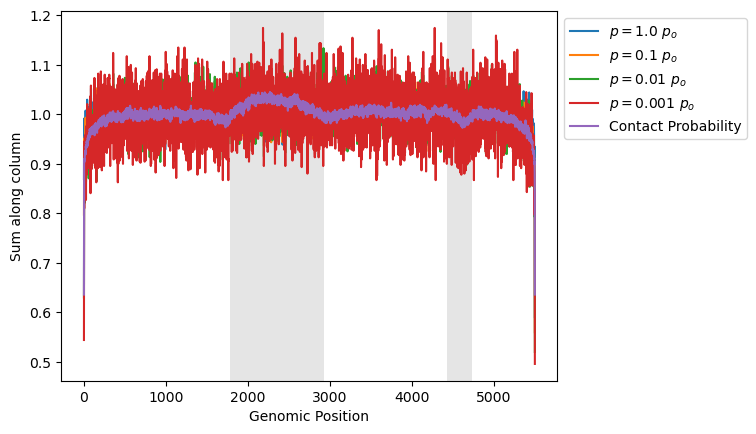

In [32]:
#Sum of columns along the chromosome for contact map of evolved structures with 1000 cuts

for i in range(len(lig_probs)):
    po_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$', 'Contact Probability']
    plt.plot(np.sum(Rescale_non_normalized_d_1000[i], axis=0))
    plt.xlabel('Genomic Position')
    plt.ylabel('Sum along column')    
plt.plot(np.sum(Rescale_non_normalized_ave_cont_map, axis=0))


plt.axvspan(1775, 2924, color='gray', alpha=0.2, lw=0)
plt.axvspan(4424, 4735, color='gray', alpha=0.2, lw=0)

plt.legend(po_legend,  bbox_to_anchor=(1, 1))

In [38]:
window = 100
win = 100
MovAve_Rescale_Ave_Cont = []
MovAve_Rescale_d_1000 = []
MovAve_Rescale_d_3000 = []
MovAve_Rescale_d_5000 = []
for j in range(5499):
    MovAve_Rescale_Ave_Cont.append(np.average(np.sum(Rescale_non_normalized_ave_cont_map, axis=0)[j:j+window]))
    MovAve_Rescale_d_1000.append(np.average(np.sum(Rescale_non_normalized_d_1000[3], axis=0)[j:j+window]))
    MovAve_Rescale_d_3000.append(np.average(np.sum(Rescale_non_normalized_d_3000[1], axis=0)[j:j+window]))
    MovAve_Rescale_d_5000.append(np.average(np.sum(Rescale_non_normalized_d_5000[0], axis=0)[j:j+window]))

Text(0.5, 0, 'Genomic Position (bp)')

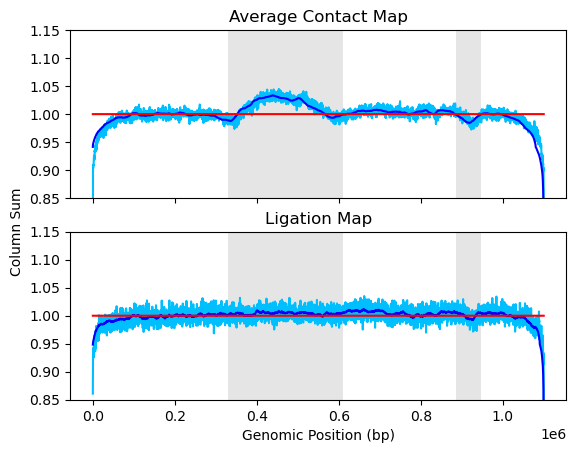

In [74]:
fig, axs = plt.subplots(2, sharex=True, sharey=True)

#fig.suptitle('Sums of columns along genomic position', x= 1, y=2.1)

xscale=np.linspace(0,5497,num=5498,dtype=int)

'''
plt.plot(200*xscale, np.sum(Rescale_non_normalized_ave_cont_map, axis=0))
plt.plot(200*xscale[0:5499], MovAve_Rescale_Ave_Cont[0:-1])
plt.plot(200*xscale, np.sum(KR_normalized_ave_cont_map, axis=0))
plt.axvspan(200*1650, 200*3050, color='gray', alpha=0.2, lw=0)
plt.axvspan(200*4424, 200*4735, color='gray', alpha=0.2, lw=0)
plt.ylim([0.8,1.2])
#plt.title('Sums of columns along genomic position Ave. Cont. Map')
plt.ylabel('Sums of column entries')
plt.xlabel('Genomic Position (bp)')
plt.legend(['Non-Norm. Ave. Contact Map', 'Moving Average Non-Norm. Ave. Contact Map', 'Knight-Ruiz Normalized'])
'''


axs[0].plot(200*xscale, np.sum(Rescale_non_normalized_ave_cont_map, axis=0),color='deepskyblue')
axs[0].plot(200*xscale[0:5499], MovAve_Rescale_Ave_Cont[0:-1],color='blue')
axs[0].plot(200*xscale, np.sum(KR_normalized_ave_cont_map, axis=0),color='red')
axs[0].axvspan(200*1650, 200*3050, color='gray', alpha=0.2, lw=0)
axs[0].axvspan(200*4424, 200*4735, color='gray', alpha=0.2, lw=0)
axs[0].set_title('Average Contact Map')
axs[0].set_ylabel('')
axs[0].set_ylim([0.85,1.15])
axs[1].plot(200*xscale, np.sum(Rescale_non_normalized_d_3000[1], axis=0),color='deepskyblue')
axs[1].plot(200*xscale, MA_Non_normalized_matrix_d_3000[1][0:-1]/np.average(MA_Non_normalized_matrix_d_3000[1][0:-1]),color='blue')
axs[1].plot(200*xscale, np.sum(KR_normalized_matrix_d_3000[1], axis=0),color='red')
axs[1].axvspan(200*1650, 200*3050, color='gray', alpha=0.2, lw=0)
axs[1].axvspan(200*4424, 200*4735, color='gray', alpha=0.2, lw=0)
axs[1].set_title('Ligation Map')
#axs[1].set_ylim([0.97,1.03])

plt.ylabel("Column Sum", y = 1)
plt.xlabel("Genomic Position (bp)")

In [42]:
#Flutuations in the sum along columns
Rescale_std_dev_d_500  = []
Rescale_std_dev_d_1000 = []
Rescale_std_dev_d_3000 = []
Rescale_std_dev_d_5000 = []

Rescale_ave_d_500  = []
Rescale_ave_d_1000 = []
Rescale_ave_d_3000 = []
Rescale_ave_d_5000 = []

for i in range(len(lig_probs)):
    Rescale_std_dev_d_500.append(np.std(np.sum(Rescale_non_normalized_d_500[i], axis=0)))
    Rescale_std_dev_d_1000.append(np.std(np.sum(Rescale_non_normalized_d_1000[i], axis=0)))
    Rescale_std_dev_d_3000.append(np.std(np.sum(Rescale_non_normalized_d_3000[i], axis=0)))
    Rescale_std_dev_d_5000.append(np.std(np.sum(Rescale_non_normalized_d_5000[i], axis=0)))
    
    Rescale_ave_d_500.append(np.average(np.sum(Rescale_non_normalized_d_500[i], axis=0)))
    Rescale_ave_d_1000.append(np.average(np.sum(Rescale_non_normalized_d_1000[i], axis=0)))
    Rescale_ave_d_3000.append(np.average(np.sum(Rescale_non_normalized_d_3000[i], axis=0)))
    Rescale_ave_d_5000.append(np.average(np.sum(Rescale_non_normalized_d_5000[i], axis=0)))

In [40]:
#Moving Averages

#Size of sliding window
window = 50

#Calculation of column sums in non-normalized matrices
Sum_Non_normalized_matrix_d_500 = []
Sum_Non_normalized_matrix_d_1000 = []
Sum_Non_normalized_matrix_d_3000 = []
Sum_Non_normalized_matrix_d_5000 = []

lmin = 1
lmax = 5499

dmax = 5500
init = 1

#Sums along column at different genomic positions
for i in range(len(lig_probs)):
    Sum_Non_normalized_matrix_d_500.append(np.sum(Non_normalized_matrix_d_500[i], axis=0))
    Sum_Non_normalized_matrix_d_1000.append(np.sum(Non_normalized_matrix_d_1000[i], axis=0))
    Sum_Non_normalized_matrix_d_3000.append(np.sum(Non_normalized_matrix_d_3000[i], axis=0))
    Sum_Non_normalized_matrix_d_5000.append(np.sum(Non_normalized_matrix_d_5000[i], axis=0))
    
Sum_Non_normalized_ave_cont_map = np.sum(Non_normalized_ave_cont_map, axis=0)
    
#for i in range(len(lig_probs)):


#Calculation of moving averages for column sums in non-normalized matrices within a certain window
MA_Non_normalized_matrix_d_500 = []
MA_Non_normalized_matrix_d_1000 = []
MA_Non_normalized_matrix_d_3000 = []
MA_Non_normalized_matrix_d_5000 = []

for m in range(len(lig_probs)):
    MovAve_d_500  = []
    MovAve_d_1000 = []
    MovAve_d_3000 = []
    MovAve_d_5000 = []
    
    for j in range(5499):
        MovAve_d_500.append(np.average(Sum_Non_normalized_matrix_d_500[m][j:j+window]))
        MovAve_d_1000.append(np.average(Sum_Non_normalized_matrix_d_1000[m][j:j+window]))
        MovAve_d_3000.append(np.average(Sum_Non_normalized_matrix_d_3000[m][j:j+window]))
        MovAve_d_5000.append(np.average(Sum_Non_normalized_matrix_d_5000[m][j:j+window]))

    MA_Non_normalized_matrix_d_500.append(MovAve_d_500)
    MA_Non_normalized_matrix_d_1000.append(MovAve_d_1000)
    MA_Non_normalized_matrix_d_3000.append(MovAve_d_3000)
    MA_Non_normalized_matrix_d_5000.append(MovAve_d_5000)

MA_Non_normalized_ave_cont_map = []
for j in range(5499):
    MA_Non_normalized_ave_cont_map.append(np.average(Sum_Non_normalized_ave_cont_map[j:j+window]))
MA_Non_normalized_ave_cont_map = np.array(MA_Non_normalized_ave_cont_map)
    
#plt.plot(Sum_Non_normalized_ave_cont_map)
#plt.plot(MovAve1)

In [64]:
#SANITY CHECK TO MAKE SURE THAT THE SUM ALONG COLUMNS MATCHES SUM ALONG ROWS
#AND THAT THE NUMPY METHOD FOR THESE SUMS IS ACTUALLY DOING WHAT IT SHOULD!

#Check if sums along rows match sums along columns

#Calculation of column sums in non-normalized matrices
Sum_Non_normalized_matrix_d_500_rows = []
Sum_Non_normalized_matrix_d_1000_rows = []
Sum_Non_normalized_matrix_d_3000_rows = []
Sum_Non_normalized_matrix_d_5000_rows = []

lmin = 1
lmax = 5499

dmax = 5500
init = 1

#Sums along rows at different genomic positions
for i in range(len(lig_probs)):
    Sum_Non_normalized_matrix_d_500_rows.append(np.sum(Non_normalized_matrix_d_500[i], axis=1))
    Sum_Non_normalized_matrix_d_1000_rows.append(np.sum(Non_normalized_matrix_d_1000[i], axis=1))
    Sum_Non_normalized_matrix_d_3000_rows.append(np.sum(Non_normalized_matrix_d_3000[i], axis=1))
    Sum_Non_normalized_matrix_d_5000_rows.append(np.sum(Non_normalized_matrix_d_5000[i], axis=1))
    
Sum_Non_normalized_ave_cont_map_rows = np.sum(Non_normalized_ave_cont_map, axis=1)

#Comparing sums along rows to sums along columns
diff_500_rc = []
diff_1000_rc = []
diff_3000_rc = []
diff_5000_rc = []

print('Comparing sums along rows to sums along columns')
for i in range(len(lig_probs)):
    
    diff_500_rc.append(np.max(np.abs(Sum_Non_normalized_matrix_d_500_rows[i]-Sum_Non_normalized_matrix_d_500[i])))
    diff_1000_rc.append(np.max(np.abs(Sum_Non_normalized_matrix_d_1000_rows[i]-Sum_Non_normalized_matrix_d_1000[i])))
    diff_3000_rc.append(np.max(np.abs(Sum_Non_normalized_matrix_d_3000_rows[i]-Sum_Non_normalized_matrix_d_3000[i])))
    diff_5000_rc.append(np.max(np.abs(Sum_Non_normalized_matrix_d_5000_rows[i]-Sum_Non_normalized_matrix_d_5000[i])))
    
    
    print(diff_500_rc[i], np.max(np.abs(Sum_Non_normalized_matrix_d_500_rows[i])), np.max(np.abs(Sum_Non_normalized_matrix_d_500[i])))
    print(diff_1000_rc[i], np.max(np.abs(Sum_Non_normalized_matrix_d_1000_rows[i])), np.max(np.abs(Sum_Non_normalized_matrix_d_1000[i])))
    print(diff_3000_rc[i], np.max(np.abs(Sum_Non_normalized_matrix_d_3000_rows[i])), np.max(np.abs(Sum_Non_normalized_matrix_d_3000[i])))
    print(diff_5000_rc[i], np.max(np.abs(Sum_Non_normalized_matrix_d_5000_rows[i])), np.max(np.abs(Sum_Non_normalized_matrix_d_5000[i])))
    

#Calculation of column sums in non-normalized matrices
Sum_Non_normalized_matrix_d_500_dumb = []
Sum_Non_normalized_matrix_d_1000_dumb = []
Sum_Non_normalized_matrix_d_3000_dumb = []
Sum_Non_normalized_matrix_d_5000_dumb = []    
    
#Calculating sums along rows and columns the dumb way just to check!

for i in range(len(lig_probs)):
    
    Mat500  = np.zeros(5498)
    Mat1000 = np.zeros(5498)
    Mat3000 = np.zeros(5498)
    Mat5000 = np.zeros(5498)
    
    for j in range(5498):
        Mat500[j]  = np.sum(Non_normalized_matrix_d_500[i][:,j])
        Mat1000[j] = np.sum(Non_normalized_matrix_d_1000[i][:,j])
        Mat3000[j] = np.sum(Non_normalized_matrix_d_3000[i][:,j])
        Mat5000[j] = np.sum(Non_normalized_matrix_d_5000[i][:,j])

    Sum_Non_normalized_matrix_d_500_dumb.append(Mat500)
    Sum_Non_normalized_matrix_d_1000_dumb.append(Mat1000)
    Sum_Non_normalized_matrix_d_3000_dumb.append(Mat3000)
    Sum_Non_normalized_matrix_d_5000_dumb.append(Mat5000)
    
print('Comparing numpy sums along columns to dumb sums along columns')
diff_500_cd = []
diff_1000_cd = []
diff_3000_cd = []
diff_5000_cd = []

for i in range(len(lig_probs)):
    
    diff_500_cd.append(np.max(np.abs(Sum_Non_normalized_matrix_d_500_dumb[i]-Sum_Non_normalized_matrix_d_500[i])))
    diff_1000_cd.append(np.max(np.abs(Sum_Non_normalized_matrix_d_1000_dumb[i]-Sum_Non_normalized_matrix_d_1000[i])))
    diff_3000_cd.append(np.max(np.abs(Sum_Non_normalized_matrix_d_3000_dumb[i]-Sum_Non_normalized_matrix_d_3000[i])))
    diff_5000_cd.append(np.max(np.abs(Sum_Non_normalized_matrix_d_5000_dumb[i]-Sum_Non_normalized_matrix_d_5000[i])))
    
    print(diff_500_cd[i], np.max(np.abs(Sum_Non_normalized_matrix_d_500_dumb[i])), np.max(np.abs(Sum_Non_normalized_matrix_d_500[i])))
    print(diff_1000_cd[i], np.max(np.abs(Sum_Non_normalized_matrix_d_1000_dumb[i])), np.max(np.abs(Sum_Non_normalized_matrix_d_1000[i])))
    print(diff_3000_cd[i], np.max(np.abs(Sum_Non_normalized_matrix_d_3000_dumb[i])), np.max(np.abs(Sum_Non_normalized_matrix_d_3000[i])))
    print(diff_5000_cd[i], np.max(np.abs(Sum_Non_normalized_matrix_d_5000_dumb[i])), np.max(np.abs(Sum_Non_normalized_matrix_d_5000[i])))
    

Comparing sums along rows to sums along columns
2.6645352591003757e-15 0.1824 0.1824000000000022
7.66053886991358e-15 0.3436 0.34359999999999236
3.297362383136715e-14 0.7950000000000002 0.7949999999999873
4.451994328746878e-14 0.9764000000000002 0.9763999999999895
2.3037127760972e-15 0.16400000000000003 0.1640000000000014
4.413136522884997e-15 0.30820000000000003 0.3081999999999971
3.097522238704187e-14 0.7208000000000001 0.7207999999999841
4.1744385725905886e-14 0.8822000000000001 0.8821999999999802
1.0130785099704553e-15 0.1052 0.10520000000000093
3.1086244689504383e-15 0.2122 0.2122000000000021
1.9484414082171497e-14 0.504 0.5039999999999917
2.0539125955565396e-14 0.534 0.53399999999999
1.1796119636642288e-16 0.0464 0.04639999999999996
9.71445146547012e-16 0.10700000000000001 0.10700000000000066
6.661338147750939e-15 0.3316 0.33159999999999523
2.525757381022231e-15 0.23360000000000003 0.23360000000000067
Comparing numpy sums along columns to dumb sums along columns
2.664535259100375

In [69]:
#Flutuations in the sum along columns
std_dev_d_500  = []
std_dev_d_1000 = []
std_dev_d_3000 = []
std_dev_d_5000 = []

ave_d_500  = []
ave_d_1000 = []
ave_d_3000 = []
ave_d_5000 = []

for i in range(len(lig_probs)):
    std_dev_d_500.append(np.std(Sum_Non_normalized_matrix_d_500[i]))
    std_dev_d_1000.append(np.std(Sum_Non_normalized_matrix_d_1000[i]))
    std_dev_d_3000.append(np.std(Sum_Non_normalized_matrix_d_3000[i]))
    std_dev_d_5000.append(np.std(Sum_Non_normalized_matrix_d_5000[i]))
    
    ave_d_500.append(np.average(Sum_Non_normalized_matrix_d_500[i]))
    ave_d_1000.append(np.average(Sum_Non_normalized_matrix_d_1000[i]))
    ave_d_3000.append(np.average(Sum_Non_normalized_matrix_d_3000[i]))
    ave_d_5000.append(np.average(Sum_Non_normalized_matrix_d_5000[i]))

In [91]:
#Pearson correlation between ligation probabilities

PCorr_d_500  = []
PCorr_d_1000 = []
PCorr_d_3000 = []
PCorr_d_5000 = []

PCorr_d_500.append(sp.stats.pearsonr(Non_lig_prob_average_d_500[0][0:-10],  KR_lig_prob_average_d_500[0][0:-10])[0])
PCorr_d_500.append(sp.stats.pearsonr(Non_lig_prob_average_d_500[1][0:-10],  KR_lig_prob_average_d_500[1][0:-10])[0])
PCorr_d_500.append(sp.stats.pearsonr(Non_lig_prob_average_d_500[2][0:-10],  KR_lig_prob_average_d_500[2][0:-10])[0])
PCorr_d_500.append(sp.stats.pearsonr(Non_lig_prob_average_d_500[3][0:-10],  KR_lig_prob_average_d_500[3][0:-10])[0])

PCorr_d_1000.append(sp.stats.pearsonr(Non_lig_prob_average_d_1000[0][0:-10],  KR_lig_prob_average_d_1000[0][0:-10])[0])
PCorr_d_1000.append(sp.stats.pearsonr(Non_lig_prob_average_d_1000[1][0:-10],  KR_lig_prob_average_d_1000[1][0:-10])[0])
PCorr_d_1000.append(sp.stats.pearsonr(Non_lig_prob_average_d_1000[2][0:-10],  KR_lig_prob_average_d_1000[2][0:-10])[0])
PCorr_d_1000.append(sp.stats.pearsonr(Non_lig_prob_average_d_1000[3][0:-10],  KR_lig_prob_average_d_1000[3][0:-10])[0])

PCorr_d_3000.append(sp.stats.pearsonr(Non_lig_prob_average_d_3000[0][0:-10],  KR_lig_prob_average_d_3000[0][0:-10])[0])
PCorr_d_3000.append(sp.stats.pearsonr(Non_lig_prob_average_d_3000[1][0:-10],  KR_lig_prob_average_d_3000[1][0:-10])[0])
PCorr_d_3000.append(sp.stats.pearsonr(Non_lig_prob_average_d_3000[2][0:-10],  KR_lig_prob_average_d_3000[2][0:-10])[0])
PCorr_d_3000.append(sp.stats.pearsonr(Non_lig_prob_average_d_3000[3][0:-10],  KR_lig_prob_average_d_3000[3][0:-10])[0])

PCorr_d_5000.append(sp.stats.pearsonr(Non_lig_prob_average_d_5000[0][0:-10],  KR_lig_prob_average_d_5000[0][0:-10])[0])
PCorr_d_5000.append(sp.stats.pearsonr(Non_lig_prob_average_d_5000[1][0:-10],  KR_lig_prob_average_d_5000[1][0:-10])[0])
PCorr_d_5000.append(sp.stats.pearsonr(Non_lig_prob_average_d_5000[2][0:-10],  KR_lig_prob_average_d_5000[2][0:-10])[0])
PCorr_d_5000.append(sp.stats.pearsonr(Non_lig_prob_average_d_5000[3][0:-10],  KR_lig_prob_average_d_5000[3][0:-10])[0])


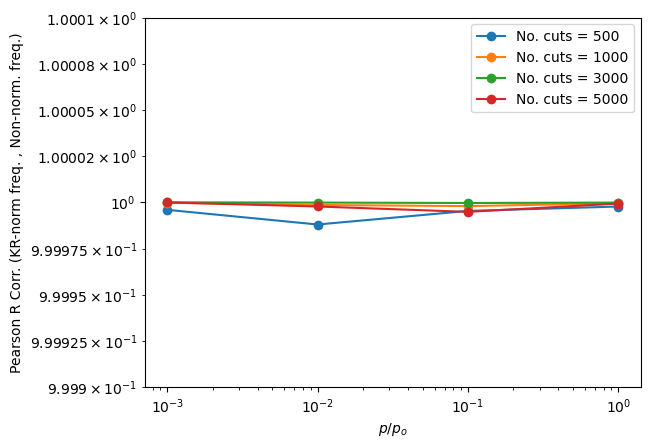

In [92]:
plt.plot(lig_probs, PCorr_d_500, marker ='o')
plt.plot(lig_probs, PCorr_d_1000, marker ='o')
plt.plot(lig_probs, PCorr_d_3000, marker ='o')
plt.plot(lig_probs, PCorr_d_5000, marker ='o')
plt.ylim(0.9999,1.0001)
plt.xscale("log")
plt.yscale("log")

plt.xlabel(r'$p/p_{o} $')
plt.ylabel('Pearson R Corr. (KR-norm freq. , Non-norm. freq.)')

plt.legend(cuts_legend)

#current_values = plt.gca().get_yticks()
#plt.gca().set_yticklabels(['{:.00000000000000%}'.format(x) for x in current_values])
plt.show()

In [82]:
#Pearson Correlation Matrix M*
#If M is the non-normalized Hi-C Map and M* is its corresponding KR-normalized map,
#then the Pearson Correlation Matrix M* is defined as follows:
#M*_(i,j) is the correlation coefficient between row 'i' and column 'j' of M*

In [83]:
sp.stats.pearsonr(KR_normalized_matrix_d_500[0][223][:],  KR_normalized_matrix_d_500[0][:][345])

PearsonRResult(statistic=0.004497422300880853, pvalue=0.7388301169634073)

In [86]:
#Pearson Correlation Matrix M*

C_KR_normalized_matrix_d_500 = []
C_KR_normalized_matrix_d_1000 = []
C_KR_normalized_matrix_d_3000 = []
C_KR_normalized_matrix_d_5000 = []



for m in range(len(lig_probs)):
    C_KR_normalized_matrix_d_500.append(np.corrcoef(KR_normalized_matrix_d_500[m]))
    C_KR_normalized_matrix_d_1000.append(np.corrcoef(KR_normalized_matrix_d_1000[m]))
    C_KR_normalized_matrix_d_3000.append(np.corrcoef(KR_normalized_matrix_d_1000[m]))
    C_KR_normalized_matrix_d_5000.append(np.corrcoef(KR_normalized_matrix_d_1000[m]))
    
    
C_Non_normalized_matrix_d_500 = []
C_Non_normalized_matrix_d_1000 = []
C_Non_normalized_matrix_d_3000 = []
C_Non_normalized_matrix_d_5000 = []
    
for m in range(len(lig_probs)):
    C_Non_normalized_matrix_d_500.append(np.corrcoef(Non_normalized_matrix_d_500[m]))
    C_Non_normalized_matrix_d_1000.append(np.corrcoef(Non_normalized_matrix_d_1000[m]))
    C_Non_normalized_matrix_d_3000.append(np.corrcoef(Non_normalized_matrix_d_1000[m]))
    C_Non_normalized_matrix_d_5000.append(np.corrcoef(Non_normalized_matrix_d_1000[m]))    

C_Non_normalized_ave_cont_map = np.corrcoef(Non_normalized_ave_cont_map)
C_KR_normalized_ave_cont_map = np.corrcoef(KR_normalized_ave_cont_map)

In [180]:
#First Principal Components of Non-normalized and KR-normalized Pearson Correlation Matrices

FPC_Non_d_500  = []
FPC_KR_d_500  = []
S_Non_d_500  = []
S_KR_d_500  = []

for m in range(len(lig_probs)):
    
    U_KR,  S_KR,  VT_KR  = np.linalg.svd(C_KR_normalized_matrix_d_500[m])
    U_Non, S_Non, VT_Non = np.linalg.svd(C_Non_normalized_matrix_d_500[m])
    
    FPC_KR_d_500.append(U_KR[:,0])
    FPC_Non_d_500.append(U_Non[:,0])
    
    S_KR_d_500.append(S_KR)
    S_Non_d_500.append(S_Non)
    
    print('Ncuts 500')

Ncuts 500
Ncuts 500
Ncuts 500
Ncuts 500


In [92]:
#First Principal Components of Non-normalized and KR-normalized Pearson Correlation Matrices

FPC_Non_d_500  = []
FPC_Non_d_1000 = []
FPC_Non_d_3000 = []
FPC_Non_d_5000 = []

FPC_KR_d_500  = []
FPC_KR_d_1000 = []
FPC_KR_d_3000 = []
FPC_KR_d_5000 = []

S_Non_d_500  = []
S_Non_d_1000 = []
S_Non_d_3000 = []
S_Non_d_5000 = []

S_KR_d_500  = []
S_KR_d_1000 = []
S_KR_d_3000 = []
S_KR_d_5000 = []

for m in range(len(lig_probs)):
    
    U_KR,  S_KR,  VT_KR  = np.linalg.svd(C_KR_normalized_matrix_d_500[m])
    U_Non, S_Non, VT_Non = np.linalg.svd(C_Non_normalized_matrix_d_500[m])
    
    FPC_KR_d_500.append(U_KR[:,0])
    FPC_Non_d_500.append(U_Non[:,0])
    
    S_KR_d_500.append(S_KR)
    S_Non_d_500.append(S_Non)
    
    print('Ncuts 500')
    
    U_KR,  S_KR,  VT_KR  = np.linalg.svd(C_KR_normalized_matrix_d_1000[m])
    U_Non, S_Non, VT_Non = np.linalg.svd(C_Non_normalized_matrix_d_1000[m])
    
    FPC_KR_d_1000.append(U_KR[:,0])
    FPC_Non_d_1000.append(U_Non[:,0])
    
    S_KR_d_1000.append(S_KR)
    S_Non_d_1000.append(S_Non)
          
    print('Ncuts 1000')
    
    U_KR,  S_KR,  VT_KR  = np.linalg.svd(C_KR_normalized_matrix_d_3000[m])
    U_Non, S_Non, VT_Non = np.linalg.svd(C_Non_normalized_matrix_d_3000[m])
    
    FPC_KR_d_3000.append(U_KR[:,0])
    FPC_Non_d_3000.append(U_Non[:,0])
    
    S_KR_d_3000.append(S_KR)
    S_Non_d_3000.append(S_Non)
    
    print('Ncuts 3000')    
          
    U_KR,  S_KR,  VT_KR  = np.linalg.svd(C_KR_normalized_matrix_d_5000[m])
    U_Non, S_Non, VT_Non = np.linalg.svd(C_Non_normalized_matrix_d_5000[m])
    
    FPC_KR_d_5000.append(U_KR[:,0])
    FPC_Non_d_5000.append(U_Non[:,0])
    
    S_KR_d_5000.append(S_KR)
    S_Non_d_5000.append(S_Non)
          
    print('Ncuts 5000')
    
    print(m, ' probability rate')

    
U_CM_Non, S_CM_Non, VT_CM_Non = np.linalg.svd(C_Non_normalized_ave_cont_map)
U_CM_KR,  S_CM_KR,  VT_CM_KR  = np.linalg.svd(C_KR_normalized_ave_cont_map)

FPC_CM_Non = U_CM_Non[:,0]
FPC_CM_KR  = U_CM_KR[:,0]

Ncuts 500
Ncuts 1000
Ncuts 3000
Ncuts 5000
0  probability rate
Ncuts 500
Ncuts 1000
Ncuts 3000
Ncuts 5000
1  probability rate
Ncuts 500
Ncuts 1000
Ncuts 3000
Ncuts 5000
2  probability rate
Ncuts 500
Ncuts 1000
Ncuts 3000
Ncuts 5000
3  probability rate


In [96]:
#plt.matshow(C_Non_normalized_ave_cont_map, cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]),vmin=0, vmax=1e-6)

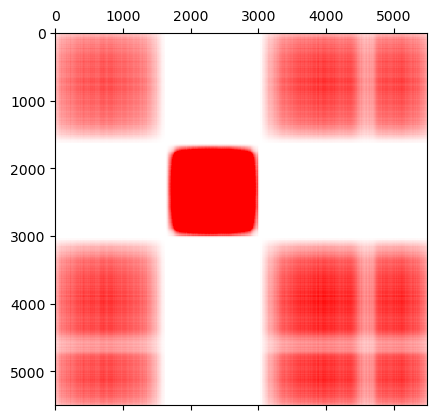

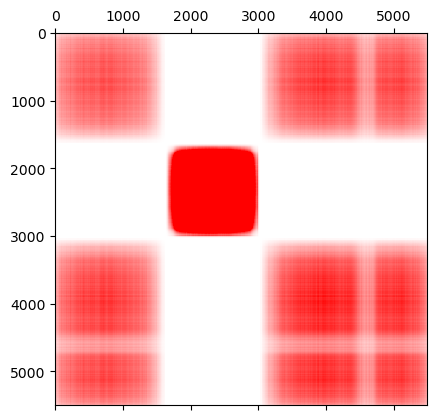

In [ ]:
#Rank 1 approximation of contact map on the basis of FPC alone, for non-normalized and normalized matrices

q = [FPC_CM_Non]
M = np.matmul(np.transpose(q),q)
plt.matshow(M, cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]),vmin=0, vmax=1e-4)

q = [FPC_CM_KR]
M = np.matmul(np.transpose(q),q)
plt.matshow(M, cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]),vmin=0, vmax=1e-4)

In [46]:
#Random Matrix Control
#We calculate the singular value spectrum of Pearson Correlation matrix for random symmetric and non-symmetric matrices, with and without normalization, as control to contrast with the Hi-C and contact maps

#Create Random Non-symmetric and Symmetric Matrices
np.random.seed(seed=726)
RanMatrixSize = 5498
RanMatrix_Asymm_Non = np.random.rand(RanMatrixSize,RanMatrixSize)
RanMatrix_Symm_Non = copy.deepcopy(RanMatrix_Asymm_Non)
for i in range(RanMatrixSize):
    for j in range(i+1, RanMatrixSize):
        RanMatrix_Symm_Non[j][i] = RanMatrix_Symm_Non[i][j]
        #print(i, j, RanMatrix_Non[i][j], RanMatrix_Non[j][i])

#Normalize Matrices
RanMatrix_Asymm_KR, n_min, n_max = NormalizeKnightRuizV2(RanMatrix_Asymm_Non, tol=1e-12, x0=None, delta=0.2, Delta=3, fl=0)
RanMatrix_Symm_KR, n_min, n_max = NormalizeKnightRuizV2(RanMatrix_Symm_Non, tol=1e-12, x0=None, delta=0.2, Delta=3, fl=0)

#Pearson Correlation of Matrices
RanCorr_Asymm_Non  = np.corrcoef(RanMatrix_Asymm_Non)
RanCorr_Asymm_KR   = np.corrcoef(RanMatrix_Asymm_KR)
RanCorr_Symm_Non   = np.corrcoef(RanMatrix_Symm_Non)
RanCorr_Symm_KR    = np.corrcoef(RanMatrix_Symm_KR)

#Singular Value Decomposition / First Principal Components of Matrices
U_Non, S_Non, VT_Non = np.linalg.svd(RanCorr_Asymm_Non)
U_KR,  S_KR,  VT_KR  = np.linalg.svd(RanCorr_Asymm_KR)
FPC_Ran_Asymm_Non = U_Non[:,0]
FPC_Ran_Asymm_KR  = U_KR[:,0]
S_Ran_Asymm_Non = S_Non    
S_Ran_Asymm_KR  = S_KR

U_Non, S_Non, VT_Non = np.linalg.svd(RanCorr_Symm_Non)
U_KR,  S_KR,  VT_KR  = np.linalg.svd(RanCorr_Symm_KR)
FPC_Ran_Symm_Non = U_Non[:,0]
FPC_Ran_Symm_KR  = U_KR[:,0]
S_Ran_Symm_Non = S_Non    
S_Ran_Symm_KR  = S_KR

In [191]:
print(np.sum(RanMatrix_Asymm_Non, axis=0))
print(np.sum(RanMatrix_Symm_Non, axis=0))
print(np.sum(RanMatrix_Asymm_KR, axis=0))
print(np.sum(RanMatrix_Symm_KR, axis=0))
print(S_Ran_Asymm_Non==S_Ran_Asymm_KR)
print(S_Ran_Symm_Non==S_Ran_Symm_KR)
print(S_Ran_Asymm_KR==S_Ran_Symm_KR)
print(S_Ran_Asymm_Non==S_Ran_Symm_Non)

[2763.7028824  2786.60437991 2762.71055047 ... 2723.91231717 2765.8399346
 2768.32641558]
[2774.48254054 2751.61445575 2741.20626866 ... 2722.80572606 2765.39303835
 2768.32641558]
[0.99606486 1.01256901 1.00773683 ... 1.00041039 1.00016512 1.        ]
[1. 1. 1. ... 1. 1. 1.]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]


In [146]:
print(sp.stats.pearsonr(S_Ran_Asymm_Non,S_Ran_Asymm_KR), sp.stats.pearsonr(S_Ran_Symm_Non,S_Ran_Symm_KR))

PearsonRResult(statistic=0.9999988923247578, pvalue=0.0) PearsonRResult(statistic=0.999999912034188, pvalue=0.0)


Text(0.5, 0, 'Singular Value Index')

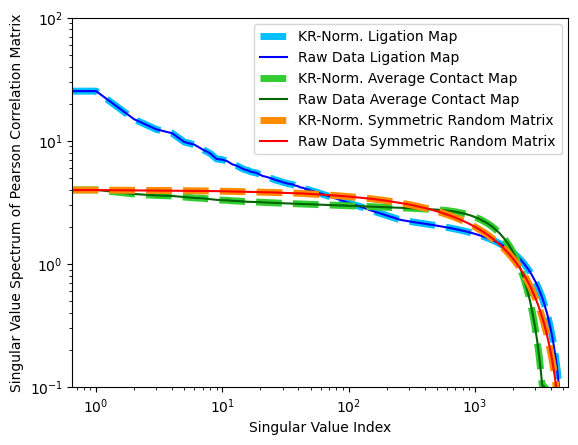

In [68]:
plt.plot(S_KR_d_3000[1],linewidth=5.0,linestyle='dashed',color='deepskyblue')
plt.plot(S_Non_d_3000[1],color='blue')
plt.plot(S_CM_KR,linewidth=5.0,linestyle='dashed',color='limegreen')
plt.plot(S_CM_Non,color='darkgreen')
plt.plot(S_Ran_Symm_KR, linewidth=5.0,linestyle='dashed',color='darkorange')
plt.plot(S_Ran_Symm_Non,color='red')
#plt.plot(S_Ran_Asymm_KR, linewidth=5.0)
#plt.plot(S_Ran_Asymm_Non)
#plt.plot(Sum_Non_normalized_ave_cont_map/10)
plt.ylabel('Singular Value Spectrum of Pearson Correlation Matrix')
plt.yscale("log")
plt.xscale("log")
plt.xlim([-100,5500])
plt.ylim([0.1,100])
plt.legend(['KR-Norm. Ligation Map', 'Raw Data Ligation Map', 'KR-Norm. Average Contact Map', 'Raw Data Average Contact Map', 'KR-Norm. Symmetric Random Matrix', 'Raw Data Symmetric Random Matrix', 'KR-Norm. Asymmetric Random Matrix', 'Raw Data Asymmetric Random Matrix'])
plt.xlabel('Singular Value Index')

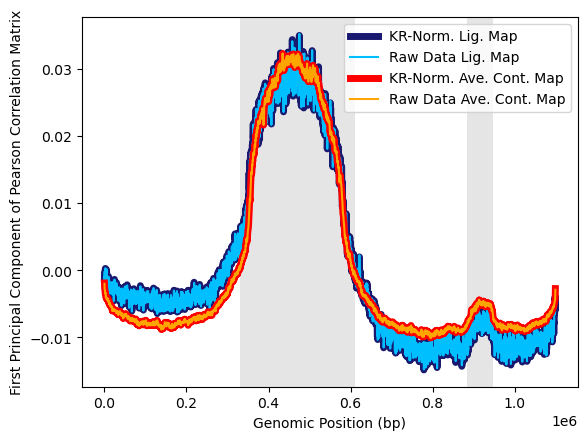

In [83]:
xscale=np.linspace(0,5497,num=5498,dtype=int)

plt.plot(200*xscale, -1*FPC_KR_d_3000[-1],linewidth=5.0,color='midnightblue')
plt.plot(200*xscale, -1*FPC_Non_d_3000[-1],color='deepskyblue')
plt.plot(200*xscale, -1*FPC_CM_KR,linewidth=5.0, color='red')
plt.plot(200*xscale, -1*FPC_CM_Non, color='orange')
#plt.plot(FPC_Ran_Non)
#plt.plot(Sum_Non_normalized_ave_cont_map/10)
#plt.axvspan(1775, 2924, color='gray', alpha=0.2, lw=0)
plt.axvspan(200*1650, 200*3050, color='gray', alpha=0.2, lw=0)
plt.axvspan(200*4424, 200*4735, color='gray', alpha=0.2, lw=0)
plt.ylabel('First Principal Component of Pearson Correlation Matrix')
plt.xlabel('Genomic Position (bp)')
plt.legend(['KR-Norm. Lig. Map', 'Raw Data Lig. Map', 'KR-Norm. Ave. Cont. Map', 'Raw Data Ave. Cont. Map'])

In [ ]:
output_dir_KR = "../../outputs/KR"

KR_file = output_dir_KR+'/KR.npz'

np.savez_compressed(KR_file, C_KR_normalized_matrix_d_500=C_KR_normalized_matrix_d_500, C_KR_normalized_matrix_d_1000=C_KR_normalized_matrix_d_1000, C_KR_normalized_matrix_d_3000=C_KR_normalized_matrix_d_3000, C_KR_normalized_matrix_d_5000=C_KR_normalized_matrix_d_5000, 
                    C_Non_normalized_matrix_d_500=C_Non_normalized_matrix_d_500, C_Non_normalized_matrix_d_1000=C_Non_normalized_matrix_d_1000, C_Non_normalized_matrix_d_3000=C_Non_normalized_matrix_d_3000, C_Non_normalized_matrix_d_5000=C_Non_normalized_matrix_d_5000, 
                    C_Non_normalized_ave_cont_map=C_Non_normalized_ave_cont_map, C_KR_normalized_ave_cont_map=C_KR_normalized_ave_cont_map,
                    FPC_Non_d_500=FPC_Non_d_500, FPC_Non_d_1000=FPC_Non_d_1000, FPC_Non_d_3000=FPC_Non_d_3000, FPC_Non_d_5000=FPC_Non_d_5000, FPC_KR_d_500=FPC_KR_d_500, FPC_KR_d_1000=FPC_KR_d_1000, FPC_KR_d_3000=FPC_KR_d_3000, FPC_KR_d_5000=FPC_KR_d_5000,
                    S_Non_d_500=S_Non_d_500, S_Non_d_1000=S_Non_d_1000, S_Non_d_3000=S_Non_d_3000, S_Non_d_5000=S_Non_d_5000, S_KR_d_500=S_KR_d_500, S_KR_d_1000=S_KR_d_1000, S_KR_d_3000=S_KR_d_3000, S_KR_d_5000=S_KR_d_5000, FPC_CM_Non=FPC_CM_Non, FPC_CM_KR=FPC_CM_KR, S_CM_KR=S_CM_KR, S_CM_Non=S_CM_Non,
                    RanMatrix_Asymm_Non=RanMatrix_Asymm_Non, RanMatrix_Symm_Non=RanMatrix_Symm_Non, RanMatrix_Asymm_KR=RanMatrix_Asymm_KR, RanMatrix_Symm_KR=RanMatrix_Symm_KR,
                    RanCorr_Asymm_Non=RanCorr_Asymm_Non, RanCorr_Asymm_KR=RanCorr_Asymm_KR,   RanCorr_Symm_Non=RanCorr_Symm_Non,   RanCorr_Symm_KR=RanCorr_Symm_KR,    
                    FPC_Ran_Asymm_Non=FPC_Ran_Asymm_Non, FPC_Ran_Asymm_KR=FPC_Ran_Asymm_KR, S_Ran_Asymm_Non=S_Ran_Asymm_Non,  S_Ran_Asymm_KR=S_Ran_Asymm_KR,  
                    FPC_Ran_Symm_Non=FPC_Ran_Symm_Non, FPC_Ran_Symm_KR=FPC_Ran_Symm_KR,  S_Ran_Symm_Non=S_Ran_Symm_Non,   S_Ran_Symm_KR=S_Ran_Symm_KR)